<a href="https://colab.research.google.com/github/jotaeleb/tif-ciencias-de-datos/blob/main/notebooks/proyecto_modelado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️TIF Análisis de Detección de Intrusiones en Red

**Grupo 1**: Gonza Gabriela · Casasola Hernán · Biazutti Luciano · Lera Aníbal Iván · Alvarado Marcelo

**Módulo**: Ciencias de Datos y Optimización de Modelos

**Carrera**: Tecnicatura Universitaria en Ciencias de Datos e IA Aplicada — UPATECO

---

# 1. Objetivos y Alcances



## 1.1 Objetivo del Análisis
Construir y evaluar modelos de Machine Learning capaces de clasificar automáticamente si un flujo de red (TCP/UDP) corresponde a tráfico legítimo (BENIGN) o a una intrusión (ataque informático).

## 1.2 Alcances del Proyecto
* **Fase de Datos:** Se trabaja a partir de un conjunto ya preprocesado y limpio (`dataset_limpio_submuestreo.parquet`), libre de valores nulos o infinitos detectados en la fase previa del análisis exploratorio (EDA).
* **Variables Consideradas:** El análisis comprende métricas temporales y volumétricas del flujo de red: volumen de paquetes (`Total Fwd Packets`), tiempos de inter-arribo (`Flow IAT Mean`), tamaño de payloads (`Avg Fwd Segment Size`), configuraciones de puertos y banderas de control.
* **Fase de Modelado:** El alcance incluye tres iteraciones: (1) datos originales con pesos balanceados, (2) SMOTE adaptativo (*k=3*), (3) selección de variables + optimización de hiperparámetros. Los resultados se comparan mediante validación cruzada estratificada y métricas robustas para datos desbalanceados.

## 1.3 Tipo de Problema
Se trata de un problema de clasificación supervisada multiclase.

El objetivo es mapear las características de un flujo de red a una de 7 etiquetas cualitativas categóricas discretas y mutuamente excluyentes, las cuales han sido codificadas mediante un LabelEncoder de la siguiente manera:

| Código | Clase | Descripción |
|--------|-------|-------------|
| 0 | BENIGN | Tráfico normal legítimo |
| 1 | Botnet | Redes infectadas bajo control remoto |
| 2 | Brute Force | Ataques de fuerza bruta |
| 3 | DoS-DDoS | Denegación de servicio |
| 4 | PortScan | Reconocimiento de puertos |
| 5 | Rare Attack | Ataques de infiltración inusuales |
| 6 | Web Attack | Ataques a aplicaciones web |

## 1.4 Flujo Metodológico
1. **Estrategia de Partición:** 80/20 estratificado (stratify=y).
2. **Validación Cruzada Estratificada:** StratifiedKFold con 5 pliegues.
3. **Métricas:** Recall Macro, Precision Macro, F1 Macro, Balanced Accuracy.
4. **Análisis de Confusión:** Matrices normalizadas por fila.

# 2. Análisis exploratorio de datos

## 2.1 Librerías y semilla global

In [1]:
# Instalar imbalanced-learn si no está disponible
!pip install imbalanced-learn -q

In [2]:
# Semilla global, garantiza reproducibilidad completa
import random
import numpy as np
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [3]:
# Librerías generales
import io
import time
import requests
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns
from IPython.display import display, HTML
from scipy.stats import randint, uniform

warnings.filterwarnings('ignore')

In [21]:
# Preprocesamiento, modelos y evaluación
from sklearn.base import clone
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, RandomizedSearchCV
)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [5]:
# Paleta de colores
PALETA = {
    # Identidad por algoritmo
    'DT_base':'#81C784',   # Verde claro
    'DT_smote':'#2E7D32',   # Verde oscuro
    'RF_base':'#64B5F6',   # Azul claro
    'RF_smote':'#1565C0',   # Azul oscuro
    'XGB_base':'#CE93D8',   # Violeta claro
    'XGB_smote':'#6A1B9A',   # Violeta oscuro
    # Colores auxiliares
    'highlight':'#C62828',   # Rojo para mejor resultado
    'neutral':'#90CAF9',   # Azul pálido para barras neutras
    'feature_xgb':'#7B1FA2',   # Violeta para importancia XGBoost
    'feature_anova':'#E65100',  # Naranja para importancia ANOVA
}

## 2.2 Carga Dataset limpio con submuestreo



Con 2,8 millones de filas, entrenar modelos en Colab puede consumir demasiada memoria y tiempo. Por eso vamos a utilizar una muestra de 168004 filas, que permite obtener resultados representativos con menor costo computacional.

El archivo dataset_limpio_submuestreo.parquet se carga directamente desde GitHub y ya se encuentra limpia, sin valores nulos ni columnas problemáticas, según el análisis realizado en proyecto_eda.ipynb.

In [9]:
#Esta función carga un dataset desde el repo de Github
def cargar_dataset(archivos: list) -> pd.DataFrame:
    """Descarga y concatena archivos Parquet desde el repositorio GitHub."""
    GITHUB_USER = 'jotaeleb'
    GITHUB_REPO = 'tif-ciencias-de-datos'
    GITHUB_BRANCH = 'main'
    DATASET_DIR = 'dataset'
    BASE_URL = (
        f'https://raw.githubusercontent.com/'
        f'{GITHUB_USER}/{GITHUB_REPO}/{GITHUB_BRANCH}/{DATASET_DIR}'
    )

    partes = []
    for archivo in archivos:
        url = f'{BASE_URL}/{archivo}'
        print(f'  Cargando: {url}')
        partes.append(pd.read_parquet(io.BytesIO(requests.get(url).content)))

    completo = pd.concat(partes, ignore_index=True)
    completo['Label'] = completo['Label'].str.replace(r'[^\w\s-]', '-', regex=True)
    return completo


print('Carga del dataset...')
df = cargar_dataset(['dataset_limpio_submuestreo.parquet'])
print(f'\nDimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print('\nDistribución de clases:')
df['Label'].value_counts()

Carga del dataset...
  Cargando: https://raw.githubusercontent.com/jotaeleb/tif-ciencias-de-datos/main/dataset/dataset_limpio_submuestreo.parquet

Dimensiones: 168,004 filas × 66 columnas

Distribución de clases:


,count
Label,
BENIGN,50000
PortScan,50000
DoS-DDoS,50000
Brute Force,13826
Web Attack,2159
Botnet,1956
Rare Attack,63


Este desbalance extremo (ratio 500:1 entre la mayoría y Rare Attack) es el principal desafío técnico del proyecto.

## 2.3 Síntesis del Análisis Exploratorio

### Análisis univariado de las variables predictoras

El dataset CICIDS2017 contiene **66 features numéricas** que caracterizan flujos de red (TCP/UDP) desde distintas perspectivas estadísticas: volumen de paquetes, tiempos inter-arribo (IAT), longitudes de payload, flags de control y tasas de transferencia.

Las distribuciones de estas variables presentan tres patrones recurrentes:

- **Alta asimetría positiva (skewness):** La mayoría de features de conteo y longitud (ej. `Total Fwd Packets`, `Packet Length Max`) tienen distribuciones con cola larga a la derecha. La gran masa de tráfico benigno genera valores moderados, mientras que ciertos ataques producen valores extremos. Esto justificó el uso de `RobustScaler` en las etapas de preprocesamiento.

- **Presencia de outliers extremos:** Variables como `Flow IAT Max` e `Init_Win_bytes_forward` registran valores hasta cientos de desviaciones estándar por encima de la mediana. Estos outliers no son errores: son la firma estadística de ciertos ataques (DoS, Port Scan). Eliminarlos sería una pérdida de información crítica.

- **Alta correlación entre features relacionadas:** `Fwd Packet Length Mean` y `Fwd Packet Length Max` comparten información redundante. Esta correlación motivó la selección de variables en la Sección 7.

### Análisis bivariado: variable objetivo vs. predictoras

La relación entre `Label` y las features revela separabilidad diferencial por clase:

| Clase | Feature más discriminativa | Patrón observado |
|---|---|---|
| **DoS/DDoS** | `Flow Bytes/s`, `Flow Packets/s` | Tasas de transferencia extremadamente altas |
| **PortScan** | `Destination Port`, `Flow Duration` | Conexiones cortas a múltiples puertos |
| **Brute Force** | `Fwd Packets/s`, `Init_Win_bytes_forward` | Muchos paquetes pequeños y rápidos |
| **Web Attack** | `Destination Port` (80/443), `Avg Fwd Segment Size` | Tráfico HTTP/HTTPS con payloads variables |
| **Botnet** | `Flow IAT Mean`, `Packet Length Mean` | Tráfico periódico de baja intensidad |
| **Rare Attack** | Múltiples features con valores límite | Sin patrón dominante único → difícil detección |

### Desbalance de clases: el desafío central

```
Label
BENIGN         ~73%   ████████████████████████████
DoS/DDoS       ~18%   ███████
PortScan        ~5%   ██
Brute Force     ~2%   █
Web Attack      ~1%   ▌
Botnet         ~0.5%  ▎
Rare Attack    ~0.1%  ·
```

Un modelo que prediga siempre BENIGN obtendría ~73% de accuracy. Por eso el accuracy global **no es una métrica adecuada** para este problema. Se prioriza **Recall Macro** (detectar cada tipo de ataque) sobre accuracy.

### Transformaciones aplicadas

- **Eliminación de NaN:** El dataset limpio (`dataset_limpio_submuestreo.parquet`) ya fue procesado en la Entrega 1: columnas con NaN sistemáticos (`Flow Bytes/s`, `Flow Packets/s`) fueron imputadas o descartadas según el caso.
- **Codificación del target:** `LabelEncoder` transforma las 7 clases a enteros 0–6, requisito de la API de scikit-learn y XGBoost.
- **No se aplica escalado global:** Los modelos basados en árboles (DT, RF, XGBoost) son invariantes a la escala; no requieren normalización. Esto simplifica el pipeline y evita data leakage en la validación cruzada.


# 3. Modelado

## 3.1 Preparación de los Datos

Antes de entrenar cualquier modelo necesitamos hacer dos cosas:
1. **Separar** la variable objetivo `Label` del resto de variables (features).
2. **Codificar** el `Label` como número, porque los modelos trabajan con números, no con texto.

### 3.1.1 Separar features y target

In [10]:
# Variable objetivo
y_texto = df['Label']

# Features: todas las columnas numéricas excepto Label
X = df.drop(columns=['Label'])

# Conservamos solo columnas numéricas
X = X.select_dtypes(include=np.number)

print(f'Features (X): {X.shape[1]} columnas')
print(f'Target (y): {y_texto.nunique()} clases')

Features (X): 65 columnas
Target (y): 7 clases


### 3.1.2 Codificar el target

In [11]:
# LabelEncoder convierte cada clase en un número entero.
le = LabelEncoder()
y = le.fit_transform(y_texto)

# Mostramos el mapeo para no perder la referencia
mapeo = dict(zip(le.classes_, le.transform(le.classes_)))
print('Mapeo de clases:')
for clase, numero in sorted(mapeo.items(), key=lambda x: x[1]):
    print(f'  {numero} → {clase}')

Mapeo de clases:
  0 → BENIGN
  1 → Botnet
  2 → Brute Force
  3 → DoS-DDoS
  4 → PortScan
  5 → Rare Attack
  6 → Web Attack


## 3.2 División Train / Test

Dividimos el dataset en:
- **80% entrenamiento**: los datos con los que el modelo aprende.
- **20% prueba**: los datos que el modelo nunca vio, para evaluar qué tan bien generaliza.

In [12]:
# División estratificada 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y  # mantiene la proporción de clases
)
# Arrays numpy reutilizados en todos los bucles de CV
X_train_arr = np.asarray(X_train)
y_train_arr = np.asarray(y_train)

# Pesos sobre todo X_train (usados en modelos finales y RandomizedSearchCV)
pesos_train = compute_sample_weight(class_weight='balanced', y=y_train)

print(f'Entrenamiento: {X_train.shape[0]:,} filas')
print(f'Prueba: {X_test.shape[0]:,} filas')

# Verificamos que la proporción se respetó
print('\nProporción de clases en train:')
clases_train = pd.Series(y_train).map(dict(zip(le.transform(le.classes_), le.classes_)))
print(clases_train.value_counts(normalize=True).round(3))

Entrenamiento: 134,403 filas
Prueba: 33,601 filas

Proporción de clases en train:
PortScan       0.298
BENIGN         0.298
DoS-DDoS       0.298
Brute Force    0.082
Web Attack     0.013
Botnet         0.012
Rare Attack    0.000
Name: proportion, dtype: float64


## 3.3 Configuración de Validación Cruzada

**¿Por qué usamos Validación Cruzada?**

Evaluar el modelo con una única partición de entrenamiento y prueba puede generar resultados sesgados, ya que estos dependen de cómo se realizó la división de los datos. Para obtener una evaluación más confiable, se utilizó validación cruzada, que entrena y evalúa el modelo varias veces con distintas particiones y reporta el promedio de los resultados.


**¿Por qué Stratified K-Fold?**

Con el desbalance extremo de este dataset, un K-Fold simple podría crear un fold donde la clase Rare Attack no tenga ningún ejemplo en el conjunto de evaluación. **StratifiedKFold** garantiza que cada fold tenga la misma proporción de todas las clases que el dataset completo.

**Métricas elegidas**

| Métrica | Fórmula | Por qué se usa aquí |
|---|---|---|
| **Recall Macro** | Promedio no ponderado del recall por clase | Penaliza igualmente fallar en Rare Attack que en BENIGN |
| **Precision Macro** | Promedio no ponderado de la precisión por clase | Evalúa las falsas alarmas de forma equitativa entre clases |
| **F1 Macro** | Media armónica de Precision y Recall Macro | Balance entre detección y falsas alarmas |
| **Balanced Accuracy** | Promedio de recall por clase | Equivale al Recall Macro; confirma consistencia |

**¿Por qué `macro` y no `weighted`?**

La versión `weighted` pondera cada clase por su frecuencia. Con el desbalance de este dataset, ponderar por frecuencia haría que las métricas de BENIGN (clase mayoritaria) dominen completamente el promedio, ocultando el desempeño real en los ataques minoritarios. La versión `macro` le asigna el mismo peso a Rare Attack que a BENIGN, que es exactamente lo que se quiere en un sistema de detección de intrusiones donde cada tipo de ataque importa.

In [14]:
# Validación cruzada estratificada
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

SCORING = {
    'recall_macro': make_scorer(recall_score, average='macro'),
    'precision_macro': make_scorer(precision_score, average='macro'),
    'f1_macro': make_scorer(f1_score, average='macro'),
    'balanced_accuracy': make_scorer(balanced_accuracy_score),
}

# DataFrame centralizado de resultados
df_resultados = pd.DataFrame(columns=[
    'Modelo', 'Estrategia',
    'Recall Macro', 'Precision Macro', 'F1 Macro',
    'Balanced Accuracy', 'Tiempo/fold (s)'
])

# FUNCIONES AUXILIARES GLOBALES

def mostrar_cv_resultados(cv_results: dict, nombre_modelo: str) -> None:
    """Imprime un resumen limpio de los resultados de cross_validate()."""
    print(f'\n── {nombre_modelo} ──')
    metricas = {
        'test_recall_macro': 'Recall Macro',
        'test_precision_macro': 'Precision Macro ',
        'test_f1_macro': 'F1 Macro ',
        'test_balanced_accuracy': 'Balanced Accuracy',
    }
    for key, nombre in metricas.items():
        vals = cv_results[key]
        print(f'  {nombre}: {vals.mean():.4f}  (± {vals.std():.4f})')
    print(f'  Tiempo promedio/fold : {cv_results["fit_time"].mean():.1f}s')


def registrar_resultado(nombre: str, estrategia: str, cv_results: dict) -> None:
    """Agrega una fila al DataFrame centralizado de resultados."""
    global df_resultados
    nueva_fila = pd.DataFrame([{
        'Modelo': nombre,
        'Estrategia': estrategia,
        'Recall Macro': cv_results['test_recall_macro'].mean(),
        'Precision Macro': cv_results['test_precision_macro'].mean(),
        'F1 Macro': cv_results['test_f1_macro'].mean(),
        'Balanced Accuracy': cv_results['test_balanced_accuracy'].mean(),
        'Tiempo/fold (s)': cv_results['fit_time'].mean(),
    }])
    df_resultados = pd.concat([df_resultados, nueva_fila], ignore_index=True)


def graficar_confusion(y_true, y_pred, titulo: str, le: LabelEncoder) -> None:
    """Grafica la matriz de confusión normalizada por fila usando la paleta global."""
    cm  = confusion_matrix(y_true, y_pred, normalize='true')
    fig, ax = plt.subplots(figsize=(9, 7))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    # Paleta de blues coherente con la identidad de RF (azul); neutral para matrices
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
    ax.set_title(titulo, fontsize=11, pad=12)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

def evaluar_xgboost_cv(
    modelo_base,
    X: np.ndarray,
    y: np.ndarray,
    cv: StratifiedKFold,
    usar_pesos: bool = True,
    smote_strategy: dict | None = None,
) -> dict:
    """Bucle manual de validación cruzada para XGBoost.
    Parámetros
    modelo_base: XGBClassifier sin entrenar.
    X, y: arrays numpy de entrenamiento.
    cv: instancia de StratifiedKFold.
    usar_pesos: si True, calcula sample_weight='balanced' por fold.
    smote_strategy: si se pasa un dict, aplica SMOTE dentro de cada fold
    Retorna
    dict con claves compatibles con cross_validate() de sklearn."""
    metricas = {k: [] for k in [
        'recall_macro', 'precision_macro', 'f1_macro',
        'balanced_accuracy', 'fit_time'
    ]}

    for idx_tr, idx_val in cv.split(X, y):
        modelo_fold = clone(modelo_base)
        X_tr, X_val = X[idx_tr], X[idx_val]
        y_tr, y_val = y[idx_tr], y[idx_val]

        # SMOTE dentro del fold (sin tocar X_val)
        if smote_strategy is not None:
            smote_fold = SMOTE(
                sampling_strategy=smote_strategy,
                k_neighbors=3,
                random_state=SEED
            )
            X_tr, y_tr = smote_fold.fit_resample(X_tr, y_tr)

        # Pesos calculados solo con datos de entrenamiento
        fit_kwargs = {}
        if usar_pesos:
            fit_kwargs['sample_weight'] = compute_sample_weight(
                class_weight='balanced', y=y_tr
            )

        t0 = time.time()
        modelo_fold.fit(X_tr, y_tr, **fit_kwargs)
        metricas['fit_time'].append(time.time() - t0)

        pred = modelo_fold.predict(X_val)
        metricas['recall_macro'].append(recall_score(y_val, pred, average='macro'))
        metricas['precision_macro'].append(precision_score(y_val, pred, average='macro'))
        metricas['f1_macro'].append(f1_score(y_val, pred, average='macro'))
        metricas['balanced_accuracy'].append(balanced_accuracy_score(y_val, pred))

    return {
        'test_recall_macro': np.array(metricas['recall_macro']),
        'test_precision_macro': np.array(metricas['precision_macro']),
        'test_f1_macro': np.array(metricas['f1_macro']),
        'test_balanced_accuracy': np.array(metricas['balanced_accuracy']),
        'fit_time': np.array(metricas['fit_time']),
    }

print('Configuración de CV y funciones auxiliares definidas.')
print(f'Estrategia: StratifiedKFold (5 pliegues, SEED={SEED})')
print(f'Métricas: Recall Macro, Precision Macro, F1 Macro, Balanced Accuracy')

Configuración de CV y funciones auxiliares definidas.
Estrategia: StratifiedKFold (5 pliegues, SEED=42)
Métricas: Recall Macro, Precision Macro, F1 Macro, Balanced Accuracy


## 3.4 Primera Iteración — class_weight='balanced'

En esta primera Iteración entrenamos los modelos usando el dataset tal como está, sin generar muestras sintéticas. Para compensar el desbalance extremo, usamos el parámetro `class_weight='balanced'`.

**¿Qué hace `class_weight='balanced'`?**

Debido al desbalance de clases del dataset, se utilizó class_weight='balanced', que asigna mayor importancia a las clases con menos ejemplos. De esta forma, los errores cometidos sobre clases minoritarias reciben una penalización más alta durante el entrenamiento, ayudando al modelo a mejorar su capacidad de detección en estas categorías.

### 3.4.1 Árbol de Decisión Baseline

In [15]:
dt_base = DecisionTreeClassifier(
    max_depth=15, # evita que el árbol crezca infinitamente (overfitting)
    class_weight='balanced',
    random_state=SEED
)

cv_dt_base = cross_validate(
    dt_base, X_train, y_train,
    cv=CV, scoring=SCORING, n_jobs=-1
)

mostrar_cv_resultados(cv_dt_base, 'Árbol de Decisión — class_weight')
registrar_resultado('Árbol de Decisión', 'class_weight', cv_dt_base)


── Árbol de Decisión — class_weight ──
  Recall Macro: 0.9557  (± 0.0272)
  Precision Macro : 0.9162  (± 0.0277)
  F1 Macro : 0.9314  (± 0.0245)
  Balanced Accuracy: 0.9557  (± 0.0272)
  Tiempo promedio/fold : 7.3s


El árbol de decisión demostró gran desempeño y estabilidad. Con Recall Macro ~ 95.6% y baja desviación estándar, el modelo es consistente entre folds. Su principal ventaja es el tiempo de entrenamiento (~ 7s/fold).

### 3.4.2 Random Forest Baseline

Random Forest es un modelo que combina múltiples árboles de decisión entrenados en paralelo con muestras y variables aleatorias, definiendo el resultado por votación mayoritaria. Sus mayores ventajas son que evita el overfitting (el promedio de los árboles cancela los errores individuales) y es sumamente robusto frente a outliers y datos irrelevantes.

In [16]:
rf_base = RandomForestClassifier(
    n_estimators=100, # cantidad de árboles
    max_depth=20,
    class_weight='balanced_subsample', # recalcula pesos en cada bootstrap
    random_state=SEED,
    n_jobs=-1 # paraleliza el entrenamiento usando todos los núcleos
)

cv_rf_base = cross_validate(
    rf_base, X_train, y_train,
    cv=CV, scoring=SCORING, n_jobs=-1
)

mostrar_cv_resultados(cv_rf_base, 'Random Forest — class_weight')
registrar_resultado('Random Forest', 'class_weight', cv_rf_base)


── Random Forest — class_weight ──
  Recall Macro: 0.9327  (± 0.0195)
  Precision Macro : 0.9894  (± 0.0026)
  F1 Macro : 0.9508  (± 0.0161)
  Balanced Accuracy: 0.9327  (± 0.0195)
  Tiempo promedio/fold : 72.3s


Random Forest superó al DT en Precision Macro (~ 98.9%), reduciendo drásticamente las falsas alarmas. El F1 Macro (~ 95%) es el más alto de la primera iteración, aunque con mayor costo computacional (~ 72s/fold).

### 3.4.3 XGBoost Baseline

XGBoost (*eXtreme Gradient Boosting*) construye árboles de forma secuencial: cada árbol corrige los errores del anterior. El parámetro `tree_method='hist'` activa el algoritmo de histogramas que acelera drásticamente el entrenamiento.

In [17]:
xgb_base = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    num_class=len(le.classes_),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',     # ← histogramas: hasta 10× más rápido
    random_state=SEED,
    n_jobs=-1
)

cv_xgb_base = evaluar_xgboost_cv(
    xgb_base, X_train_arr, y_train_arr, CV, usar_pesos=True
)

mostrar_cv_resultados(cv_xgb_base, 'XGBoost — class_weight')
registrar_resultado('XGBoost', 'class_weight', cv_xgb_base)


── XGBoost — class_weight ──
  Recall Macro: 0.9752  (± 0.0198)
  Precision Macro : 0.9886  (± 0.0100)
  F1 Macro : 0.9798  (± 0.0098)
  Balanced Accuracy: 0.9752  (± 0.0198)
  Tiempo promedio/fold : 94.7s


XGBoost Baseline se consolida como el mejor modelo en términos de rendimiento predictivo, alcanzando las métricas más altas de toda la comparativa (F1 Macro de ~ 98% y Balanced Accuracy de ~ 97.5%). Mostró una estabilidad excepcional entre folds y un equilibrio casi perfecto entre precisión y sensibilidad. Su única desventaja es el costo computacional, siendo el más lento de entrenar (~ 94.7s/fold).

### 3.4.4 Evaluación sobre el Test Set — Mejor Modelo

Mejor modelo (1ª Iteración): XGBoost

REPORTE — XGBoost (Test Set)


,precision,recall,f1-score,support
BENIGN,0.999,0.998,0.999,10000.000
Botnet,0.977,0.992,0.985,391.000
Brute Force,1.000,1.000,1.000,2765.000
DoS-DDoS,1.000,1.000,1.000,10000.000
PortScan,1.000,1.000,1.000,10000.000
Rare Attack,0.667,0.769,0.714,13.000
Web Attack,0.993,0.991,0.992,432.000
accuracy,0.999,0.999,0.999,0.999
macro avg,0.948,0.964,0.956,33601.000
weighted avg,0.999,0.999,0.999,33601.000


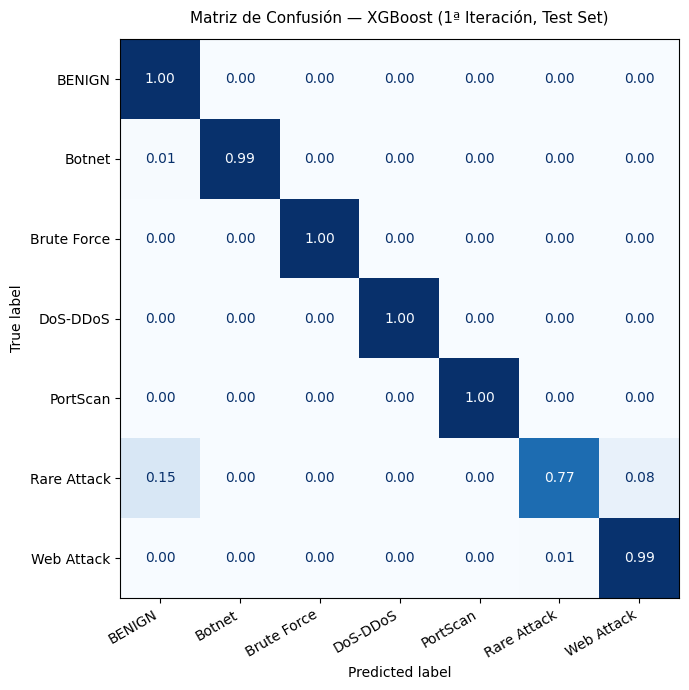

In [18]:
resultados_exp1 = {
    'Árbol de Decisión': (cv_dt_base, dt_base),
    'Random Forest': (cv_rf_base, rf_base),
    'XGBoost': (cv_xgb_base, xgb_base),
}

mejor_nombre_exp1 = max(
    resultados_exp1.keys(),
    key=lambda k: resultados_exp1[k][0]['test_f1_macro'].mean()
)
_, mejor_modelo_exp1 = resultados_exp1[mejor_nombre_exp1]
print(f'Mejor modelo (1ª Iteración): {mejor_nombre_exp1}')

# Entrenar sobre TODO X_train
if mejor_nombre_exp1 == 'XGBoost':
    mejor_modelo_exp1.fit(X_train, y_train, sample_weight=pesos_train)
else:
    mejor_modelo_exp1.fit(X_train, y_train)

y_pred_exp1 = mejor_modelo_exp1.predict(X_test)

reporte_dict = classification_report(
    y_test, y_pred_exp1,
    target_names=le.classes_,
    zero_division=0,
    output_dict=True
)
df_rep1 = pd.DataFrame(reporte_dict).transpose()
print(f'\nREPORTE — {mejor_nombre_exp1} (Test Set)')
display(df_rep1.round(3))

graficar_confusion(
    y_test, y_pred_exp1,
    f'Matriz de Confusión — {mejor_nombre_exp1} (1ª Iteración, Test Set)', le
)

XGBoost demostró un rendimiento excelente y casi perfecto en el conjunto de prueba, alcanzando un Accuracy global del 99.9% y un F1 Macro de ~95.6%. El modelo clasifica de manera impecable las categorías mayoritarias (como BENIGN, DoS-DDoS y PortScan con métricas de 1.00). Su único desafío se presenta en la clase altamente minoritaria Rare Attack (soporte de solo 13 muestras), donde la precisión disminuye a 66.7% debido a falsas alarmas que el modelo confunde principalmente con tráfico benigno (15%) o ataques web (8%), un comportamiento esperable ante un desbalance tan extremo.

## 3.5 Segunda Iteración - Aplicación de SMOTE

SMOTE es una técnica de sobremuestreo que equilibra los datasets generando datos sintéticos de la clase minoritaria, en lugar de simplemente duplicar filas (lo que causaría overfitting). Para crear estas nuevas muestras artificiales, utiliza el algoritmo k-NN para realizar una interpolación geométrica entre los datos reales más cercanos.

**Estrategia personalizada**: se definen topes controlados por clase para evitar inflación artificial del dataset.

SMOTE se aplica **dentro de cada fold** mediante `ImbPipeline` (para DT y RF) o la función `evaluar_xgboost_cv` con `smote_strategy` (para XGBoost). Esto previene data leakage: el conjunto de validación nunca ve datos sintéticos.

In [19]:
# Estrategia de muestreo con topes controlados
estrategia_muestreo = {
    'Brute Force': 20000,
    'Web Attack': 12000,
    'Botnet': 12000,
    'Rare Attack': 4000,
}

# Traducir nombres a códigos numéricos del LabelEncoder
estrategia_codificada = {
    mapeo[clase]: cantidad
    for clase, cantidad in estrategia_muestreo.items()
}

print('Estrategia de muestreo (codificada):')
for codigo, cantidad in estrategia_codificada.items():
    print(f'  {le.inverse_transform([codigo])[0]} ({codigo}): {cantidad:,}')

Estrategia de muestreo (codificada):
  Brute Force (2): 20,000
  Web Attack (6): 12,000
  Botnet (1): 12,000
  Rare Attack (5): 4,000


### 3.5.1 SMOTE + Árbol de Decisión

In [20]:
# ImbPipeline asegura que SMOTE se aplique solo en el fold de entrenamiento
dt_smote = ImbPipeline([
    ('smote', SMOTE(
        sampling_strategy=estrategia_codificada,
        k_neighbors=3,
        random_state=SEED
    )),
    ('modelo', DecisionTreeClassifier(
        max_depth=15,
        class_weight='balanced',
        random_state=SEED
    ))
])

cv_dt_smote = cross_validate(
    dt_smote, X_train, y_train,
    cv=CV, scoring=SCORING, n_jobs=-1
)

mostrar_cv_resultados(cv_dt_smote, 'Árbol de Decisión — SMOTE')
registrar_resultado('Árbol de Decisión', 'SMOTE', cv_dt_smote)


── Árbol de Decisión — SMOTE ──
  Recall Macro: 0.9560  (± 0.0187)
  Precision Macro : 0.8743  (± 0.0324)
  F1 Macro : 0.8937  (± 0.0340)
  Balanced Accuracy: 0.9560  (± 0.0187)
  Tiempo promedio/fold : 12.0s


La aplicación de SMOTE mejoró la capacidad de detección del Árbol de Decisión, manteniendo un Recall Macro elevado (~ 95.6%) y una buena estabilidad entre folds. Sin embargo, esta técnica de sobremuestreo provocó una caída notable en la Precision Macro (~ 87.4%), lo que se traduce en un mayor número de falsas alarmas en comparación con el modelo base. Su costo computacional aumentó ligeramente, requiriendo un tiempo de entrenamiento de ~ 12s/fold.

### 3.5.2 SMOTE + Random Forest

In [22]:
rf_smote = ImbPipeline([
    ('smote', SMOTE(
        sampling_strategy=estrategia_codificada,
        k_neighbors=3,
        random_state=SEED
    )),
    ('modelo', RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        class_weight='balanced_subsample',
        random_state=SEED,
        n_jobs=-1
    ))
])

cv_rf_smote = cross_validate(
    rf_smote, X_train, y_train,
    cv=CV, scoring=SCORING, n_jobs=-1
)

mostrar_cv_resultados(cv_rf_smote, 'Random Forest — SMOTE')
registrar_resultado('Random Forest', 'SMOTE', cv_rf_smote)


── Random Forest — SMOTE ──
  Recall Macro: 0.9504  (± 0.0171)
  Precision Macro : 0.9701  (± 0.0122)
  F1 Macro : 0.9568  (± 0.0128)
  Balanced Accuracy: 0.9504  (± 0.0171)
  Tiempo promedio/fold : 138.8s


Random Forest con SMOTE logró un gran equilibrio predictivo, alcanzando un F1 Macro de ~ 95.7% y manteniendo la alta estabilidad entre folds que caracteriza al algoritmo. Aunque la Precision Macro (~ 97%) sufrió una leve penalización respecto a su versión sin sobremuestreo, el modelo sigue controlando eficazmente las falsas alarmas. Su principal desventaja es el alto costo computacional, casi duplicando su tiempo de entrenamiento anterior hasta los ~138.8s/fold.

### 3.5.3 SMOTE + XGBoost

La función `evaluar_xgboost_cv` aplica SMOTE dentro de cada fold cuando se pasa `smote_strategy`, garantizando que el conjunto de validación **nunca contenga datos sintéticos** (prevención de data leakage).



In [23]:
xgb_smote_base = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    num_class=len(le.classes_),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    random_state=SEED,
    n_jobs=-1
)

cv_xgb_smote = evaluar_xgboost_cv(
    xgb_smote_base,
    X_train_arr, y_train_arr,
    CV,
    usar_pesos=False,           # SMOTE ya balancea; no duplicar señal
    smote_strategy=estrategia_codificada,
)

mostrar_cv_resultados(cv_xgb_smote, 'XGBoost — SMOTE')
registrar_resultado('XGBoost', 'SMOTE', cv_xgb_smote)


── XGBoost — SMOTE ──
  Recall Macro: 0.9613  (± 0.0233)
  Precision Macro : 0.9898  (± 0.0073)
  F1 Macro : 0.9714  (± 0.0135)
  Balanced Accuracy: 0.9613  (± 0.0233)
  Tiempo promedio/fold : 110.9s


XGBoost con SMOTE mantuvo un rendimiento excelente, logrando una excelente Precision Macro (~99%) y un F1 Macro de ~97.1%. Sin embargo, a diferencia de los modelos anteriores, la aplicación de sobremuestreo no superó a su versión baseline, mostrando una ligera disminución en el Recall Macro y mayor variabilidad entre folds. Además, incrementó su alto costo computacional, elevando el tiempo de entrenamiento a ~110.9s/fold.

### 3.5.4 Comparativa 1ª vs 2ª Iteración

In [24]:
print('Comparativa: class_weight vs SMOTE')
display(df_resultados.set_index(['Modelo', 'Estrategia']).round(4))

Comparativa: class_weight vs SMOTE


,,Recall Macro,Precision Macro,F1 Macro,Balanced Accuracy,Tiempo/fold (s)
Modelo,Estrategia,,,,,
Árbol de Decisión,class_weight,0.9557,0.9162,0.9314,0.9557,7.2525
Random Forest,class_weight,0.9327,0.9894,0.9508,0.9327,72.3027
XGBoost,class_weight,0.9752,0.9886,0.9798,0.9752,94.7341
Árbol de Decisión,SMOTE,0.9560,0.8743,0.8937,0.9560,12.0227
Random Forest,SMOTE,0.9504,0.9701,0.9568,0.9504,138.7631
XGBoost,SMOTE,0.9613,0.9898,0.9714,0.9613,110.8601


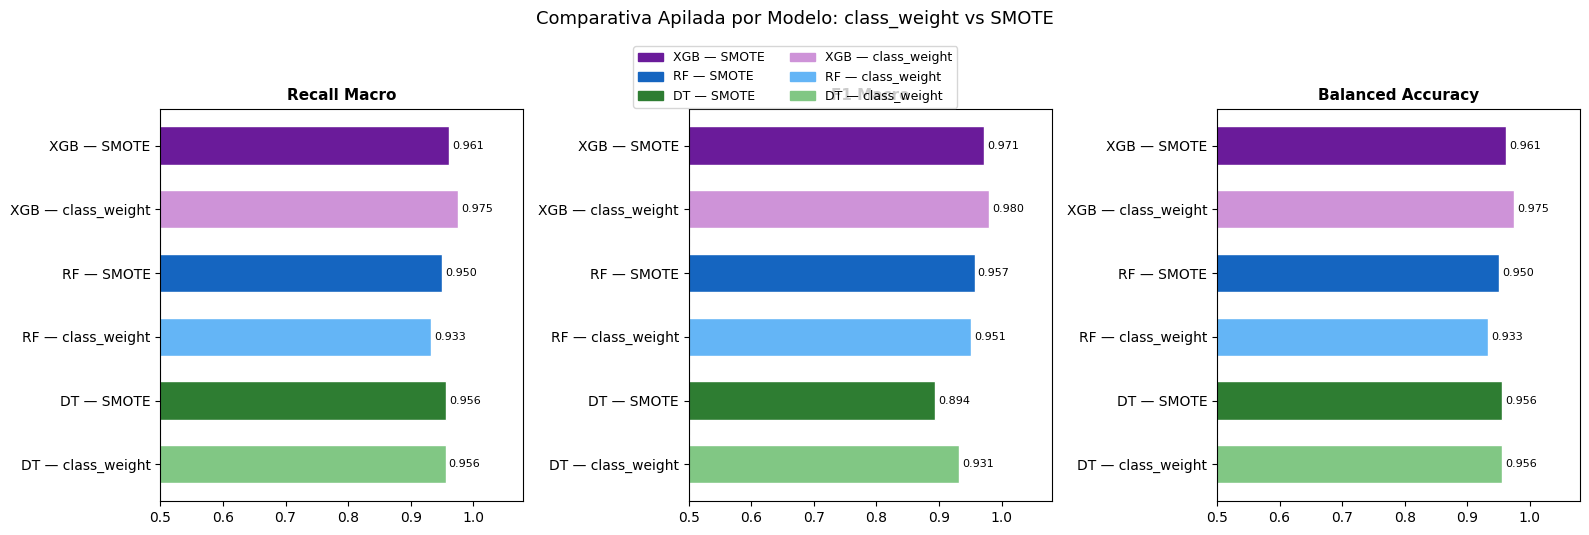

In [38]:
# Gráfico comparativo — identidad cromática por algoritmo
mapa_colores = {
    'DT — class_weight': PALETA['DT_base'],
    'DT — SMOTE': PALETA['DT_smote'],
    'RF — class_weight': PALETA['RF_base'],
    'RF — SMOTE': PALETA['RF_smote'],
    'XGB — class_weight': PALETA['XGB_base'],
    'XGB — SMOTE': PALETA['XGB_smote']
}

orden_deseado = [
    'DT — class_weight',
    'DT — SMOTE',
    'RF — class_weight',
    'RF — SMOTE',
    'XGB — class_weight',
    'XGB — SMOTE'
]

# Estandarizamos temporalmente los nombres en el DataFrame para poder ordenar correctamente
df_temp = df_resultados.copy()
df_temp['Modelo_Cod'] = df_temp['Modelo'].str.replace('Árbol de Decisión', 'DT')\
                                         .str.replace('Random Forest', 'RF')\
                                         .str.replace('XGBoost', 'XGB')
df_temp['Etiqueta_Final'] = df_temp['Modelo_Cod'] + ' — ' + df_temp['Estrategia']

# Reindexamos el DataFrame basado en el orden visual que queremos obtener
df_temp['Etiqueta_Final'] = df_temp['Etiqueta_Final'].astype('category')
df_temp['Etiqueta_Final'] = df_temp['Etiqueta_Final'].cat.set_categories(orden_deseado)
df_ordenado = df_temp.sort_values('Etiqueta_Final').reset_index(drop=True)

# Recuperamos las etiquetas y generamos los colores mapeados de forma segura
etiquetas = df_ordenado['Etiqueta_Final'].tolist()
colores_barra = [mapa_colores[etiqueta] for etiqueta in etiquetas]

# Configuración del gráfico
metricas_plot = ['Recall Macro', 'F1 Macro', 'Balanced Accuracy']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metrica in zip(axes, metricas_plot):
    valores = df_ordenado[metrica].tolist()
    bars = ax.barh(etiquetas, valores, color=colores_barra, edgecolor='white', height=0.6)

    ax.set_xlim(0.5 , 1.08)
    ax.set_title(metrica, fontsize=11, fontweight='bold')
    ax.axvline(0.5, color='grey', linestyle='--', alpha=0.4)

    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{w:.3f}', va='center', fontsize=8)

# Leyenda de identidad cromática ajustada al nuevo orden visual
leyenda_handles = [
    Patch(color=PALETA['XGB_smote'], label='XGB — SMOTE'),
    Patch(color=PALETA['RF_smote'], label='RF — SMOTE'),
    Patch(color=PALETA['DT_smote'], label='DT — SMOTE'),
    Patch(color=PALETA['XGB_base'], label='XGB — class_weight'),
    Patch(color=PALETA['RF_base'], label='RF — class_weight'),
    Patch(color=PALETA['DT_base'], label='DT — class_weight'),
]

fig.legend(
    handles=leyenda_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.0),
    ncol=2, fontsize=9, frameon=True # Organizado en 2 columnas (SMOTE vs class_weight)
)

plt.suptitle('Comparativa Apilada por Modelo: class_weight vs SMOTE', fontsize=13, y=1.06)
plt.tight_layout()
plt.show()

**Análisis Comparativo: class_weight vs. SMOTE**
* **Rendimiento general:** La estrategia class_weight resultó superior para los algoritmos basados en boosting (XGBoost), logrando el F1 Macro (~ 98%) y el Balanced Accuracy (~ 97.5%) más altos de todo el estudio.

* **Impacto de SMOTE:** El sobremuestreo benefició principalmente a Random Forest, elevando su Recall Macro de ~ 93.3% a ~ 95% y mejorando su F1 Macro general. En cambio, en el Árbol de Decisión, SMOTE provocó una degradación severa de la precisión (~ 87.4%), disparando las falsas alarmas.

* **Eficiencia computacional:** La técnica class_weight demostró ser drásticamente más eficiente. SMOTE incrementó significativamente los tiempos de entrenamiento en todos los modelos, llegando a duplicar el costo en Random Forest (~ 138.7s frente a ~7 2.3s).

XGBoost con class_weight se corona como la solución óptima. No solo ofrece el mejor balance predictivo y la mayor capacidad para identificar clases minoritarias sin destruir la precisión, sino que además lo logra con un costo computacional menor que su contraparte con SMOTE.

### 3.5.5 Selección del Modelo y Evaluación en el Test Set

In [26]:
resultados_finales = {
    'DT — class_weight': (cv_dt_base,   dt_base, False),
    'DT — SMOTE': (cv_dt_smote,  dt_smote, True),
    'RF — class_weight': (cv_rf_base,   rf_base, False),
    'RF — SMOTE': (cv_rf_smote,  rf_smote, True),
    'XGB — class_weight': (cv_xgb_base,  xgb_base, False),
    'XGB — SMOTE': (cv_xgb_smote, xgb_smote_base, True),
}

mejor_nombre_final = max(
    resultados_finales.keys(),
    key=lambda k: resultados_finales[k][0]['test_f1_macro'].mean()
)
cv_ganador, modelo_ganador, usa_smote = resultados_finales[mejor_nombre_final]

print(f'Modelo ganador (por F1 Macro en CV): {mejor_nombre_final}')
print(f' F1 Macro (CV): {cv_ganador["test_f1_macro"].mean():.4f} (± {cv_ganador["test_f1_macro"].std():.4f})')
print(f' Recall Macro (CV): {cv_ganador["test_recall_macro"].mean():.4f}')
print(f' Precision Macro (CV): {cv_ganador["test_precision_macro"].mean():.4f}')
print(f' Balanced Accuracy: {cv_ganador["test_balanced_accuracy"].mean():.4f}')

Modelo ganador (por F1 Macro en CV): XGB — class_weight
 F1 Macro (CV): 0.9798 (± 0.0098)
 Recall Macro (CV): 0.9752
 Precision Macro (CV): 0.9886
 Balanced Accuracy: 0.9752


XGBoost con la estrategia class_weight se consolida como el modelo ganador tras la validación cruzada (CV), destacando por un rendimiento predictivo excepcional y equilibrado:
* **Robustez y consistencia:** Alcanza un F1 Macro de ~ 97.98% con una desviación estándar sumamente baja ($\pm 0.0098$), lo que demuestra que el modelo es altamente estable frente a diferentes particiones de los datos.
* **Control de errores:** Muestra un equilibrio casi perfecto en la detección de ataques. Su Precision Macro (~ 98.86%) asegura una tasa de falsas alarmas ínfima, mientras que el Recall Macro y Balanced Accuracy (~ 97.52%) confirman su alta sensibilidad para capturar correctamente las diferentes clases del dataset, mitigando el impacto del desbalance.

## 3.6 Tercera Iteración - Selección de variables

El dataset original tiene 66 features de red. Muchas están altamente correlacionadas (por ejemplo, distintas estadísticas del mismo flujo: media, máximo, mínimo de packet length). Reducir la dimensionalidad tiene tres beneficios concretos:

- **Modelos más livianos**: menos features, menos memoria y tiempo de entrenamiento.
- **Menor riesgo de overfitting**: eliminar variables irrelevantes o redundantes mejora la generalización.
- **Mayor interpretabilidad**: es más fácil explicar un modelo con 15 variables que con 70.

Comparamos dos métodos de selección:

| Método | Criterio | Depende del modelo? |
|---|---|---|
| **Importancia XGBoost** | Reducción de error en cada split (gain) |  Sí |
| **SelectKBest ANOVA-F** | Separación estadística entre clases |  No |"""))

<br>

**Prevención de data leakage**: la selección de variables se realiza **dentro de cada fold** de la validación cruzada usando un `Pipeline` o la función `evaluar_xgboost_cv_con_seleccion`. Esto evita que la información del conjunto de validación influya en la elección de features.

### 3.6.1 Importancia de Variables — XGBoost

Se entrena XGBoost sobre X_train completo **únicamente para visualizar** el ranking de importancias. La selección real ocurre fold por fold en la validación cruzada.

In [27]:
# Modelo de referencia para extraer importancias (visualización)
xgb_completo = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    num_class=len(le.classes_),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    random_state=SEED,
    n_jobs=-1
)

xgb_completo.fit(X_train, y_train, sample_weight=pesos_train)

# Extraer importancias por GAIN
importancias_gain = xgb_completo.get_booster().get_score(importance_type='gain')
importancias_serie = pd.Series(importancias_gain).sort_values(ascending=False)

print(f'Features con importancia > 0 : {len(importancias_serie)}')
print(f'Features con importancia = 0 : {X_train.shape[1] - len(importancias_serie)}')
print(f'\nTop 10 features (gain):')
print(importancias_serie.head(10).round(2))

Features con importancia > 0 : 60
Features con importancia = 0 : 5

Top 10 features (gain):
Avg Bwd Segment Size       1400.73
PSH Flag Count              517.92
Fwd Packet Length Min       516.05
Fwd Packet Length Std       433.01
Bwd Packet Length Min       249.61
Fwd Packet Length Max       211.52
Bwd Packets/s               175.49
Bwd Packet Length Mean      167.97
Bwd Packet Length Std       166.29
Init_Win_bytes_backward     165.25
dtype: float64


Este reporte complementa el análisis de selección de variables y justifica por qué el modelo rinde mejor con el dataset completo:

* **Justificación del Dataset** Completo: De las 65 variables, 60 aportan valor predictivo real (importancia > 0) y solo 5 son irrelevantes. Esto explica por qué recortar a un Top-20 daña el rendimiento: se descartan 40 variables que sumaban información útil.

* **Predominio del Top-1:** Avg Bwd Segment Size (1400.73) domina de forma masiva, triplicando la ganancia de los seguidores más cercanos (PSH Flag Count: 517.92 y Fwd Packet Length Min: 516.05).

* **Perfil de las Variables Clave:** El Top-10 está monopolizado por la estructura física del tráfico (longitudes y velocidad de paquetes). La única métrica de control de flujo que logra ingresar al grupo selecto es Init_Win_bytes_backward (165.25).

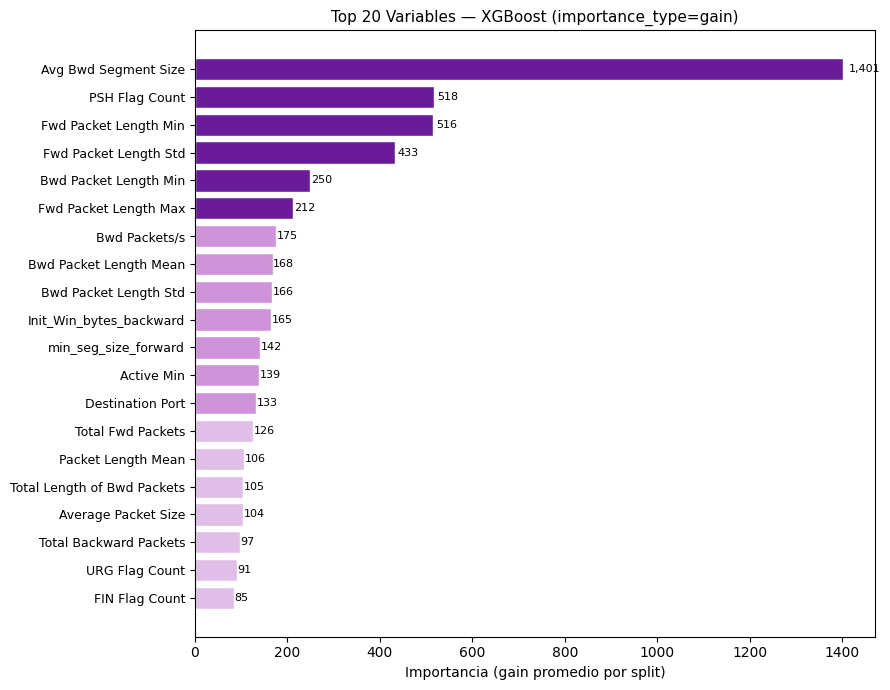

In [28]:
# Gráfico Top 20 — XGBoost Gain
K = 20
top20_gain = importancias_serie.head(K)

fig, ax = plt.subplots(figsize=(9, 7))
n = len(top20_gain)
colores_xgb = [
    PALETA['XGB_smote'] if i < n // 3 else
    PALETA['XGB_base']  if i < 2 * n // 3 else
    '#E1BEE7'
    for i in range(n)
]
ax.barh(top20_gain.index[::-1], top20_gain.values[::-1],
        color=colores_xgb[::-1], edgecolor='white')

ax.set_xlabel('Importancia (gain promedio por split)', fontsize=10)
ax.set_title(f'Top {K} Variables — XGBoost (importance_type=gain)', fontsize=11)
ax.tick_params(axis='y', labelsize=9)

for i, (feat, val) in enumerate(zip(top20_gain.index[::-1], top20_gain.values[::-1])):
    ax.text(val * 1.01, i, f'{val:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

El gráfico de ganancia promedio (gain) revela qué características aportan mayor pureza y capacidad de discriminación en las decisiones del modelo ganador:

* **Variable dominante:** Avg Bwd Segment Size lidera de forma masiva el ranking (1,401), lo que indica que el tamaño promedio de los segmentos de bajada (backward) es el indicador crítico y más determinante para separar el tráfico benigno de los diferentes tipos de ataques en la red.

* **Métricas de longitud y banderas:** Se observa una fuerte dependencia en los atributos estructurales del paquete. El bloque superior incluye el conteo de banderas PSH (PSH Flag Count: 518) junto con estadísticas clave de longitud de paquetes tanto de subida como de bajada (Fwd Packet Length Min/Std y Bwd Packet Length Min), consolidándose como el núcleo predictivo secundario.

* **Distribución de importancia:** El modelo concentra la mayor parte de su ganancia en las primeras 6 variables (barras oscuras), mientras que las 14 restantes (barras claras), asociadas a tiempos, puertos o banderas específicas (URG, FIN), actúan como refinamientos marginales con niveles de ganancia por debajo de 175.

### 3.6.2 SelectKBest con ANOVA-F

ANOVA-F (Analysis of Variance F-test) mide cuánto varía el promedio de cada feature entre las distintas clases respecto a la variación dentro de cada clase. Una feature con F-score alto separa bien las clases.

**Ventaja**: es independiente del modelo. No necesita entrenar XGBoost primero.

**Limitación**: solo captura relaciones lineales entre cada feature y el target. No detecta interacciones entre variables (algo que XGBoost sí aprende mediante los splits).


In [29]:
# Pipeline con ANOVA-F dentro de cada fold (sin leakage)
K_anova = 20

xgb_anova_modelo = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    num_class=len(le.classes_),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    random_state=SEED,
    n_jobs=-1
)

# Pipeline sklearn: ANOVA → XGBoost (el selector se fitea solo con X_tr de cada fold)
pipe_anova = SkPipeline([
    ('selector', SelectKBest(score_func=f_classif, k=K_anova)),
    ('modelo',   xgb_anova_modelo)
])

# Bucle manual para poder pasar sample_weight
metricas_anova = {k: [] for k in [
    'recall_macro', 'precision_macro', 'f1_macro', 'balanced_accuracy', 'fit_time'
]}
for idx_tr, idx_val in CV.split(X_train_arr, y_train_arr):
    pipe_fold = clone(pipe_anova)
    X_tr, X_val = X_train_arr[idx_tr], X_train_arr[idx_val]
    y_tr, y_val = y_train_arr[idx_tr], y_train_arr[idx_val]
    pesos_fold  = compute_sample_weight(class_weight='balanced', y=y_tr)

    t0 = time.time()
    pipe_fold.fit(X_tr, y_tr, modelo__sample_weight=pesos_fold)
    metricas_anova['fit_time'].append(time.time() - t0)

    pred = pipe_fold.predict(X_val)
    metricas_anova['recall_macro'].append(recall_score(y_val, pred, average='macro'))
    metricas_anova['precision_macro'].append(precision_score(y_val, pred, average='macro'))
    metricas_anova['f1_macro'].append(f1_score(y_val, pred, average='macro'))
    metricas_anova['balanced_accuracy'].append(balanced_accuracy_score(y_val, pred))

cv_xgb_anova = {f'test_{k}' if k != 'fit_time' else k: np.array(v)
                for k, v in metricas_anova.items()}

mostrar_cv_resultados(cv_xgb_anova, f'XGBoost — Top {K_anova} features (ANOVA-F, selección por fold)')

# Selector global para visualización y test set
selector_global = SelectKBest(score_func=f_classif, k=K_anova)
selector_global.fit(X_train, y_train)
f_scores      = pd.Series(selector_global.scores_, index=X_train.columns).sort_values(ascending=False)
features_anova = f_scores.head(K_anova).index.tolist()
X_train_anova  = X_train[features_anova]
X_test_anova   = X_test[features_anova]

print(f'\nTop {K_anova} features por ANOVA-F:')
for i, feat in enumerate(features_anova, 1):
    print(f'  {i:2d}. {feat}  (F={f_scores[feat]:,.0f})')


── XGBoost — Top 20 features (ANOVA-F, selección por fold) ──
  Recall Macro: 0.9194  (± 0.0186)
  Precision Macro : 0.7445  (± 0.0058)
  F1 Macro : 0.7904  (± 0.0056)
  Balanced Accuracy: 0.9194  (± 0.0186)
  Tiempo promedio/fold : 46.3s

Top 20 features por ANOVA-F:
   1. Bwd Packet Length Mean  (F=21,013)
   2. Avg Bwd Segment Size  (F=21,013)
   3. PSH Flag Count  (F=19,386)
   4. Bwd Packet Length Max  (F=18,656)
   5. Packet Length Mean  (F=18,514)
   6. Packet Length Std  (F=18,394)
   7. Average Packet Size  (F=18,189)
   8. Bwd Packet Length Std  (F=17,920)
   9. Max Packet Length  (F=17,535)
  10. Idle Max  (F=11,175)
  11. Flow IAT Max  (F=11,174)
  12. Fwd IAT Std  (F=11,166)
  13. Packet Length Variance  (F=11,165)
  14. Fwd IAT Max  (F=11,077)
  15. Idle Mean  (F=10,696)
  16. Flow IAT Std  (F=9,964)
  17. Idle Min  (F=9,758)
  18. ACK Flag Count  (F=8,761)
  19. Flow Duration  (F=7,806)
  20. Fwd IAT Total  (F=7,788)


La selección de variables mediante ANOVA-F provocó una degradación drástica en el rendimiento predictivo del modelo, reduciendo el F1 Macro a ~ 79.04%. Aunque mantiene un Recall Macro aceptable (~ 91.94%), la Precision Macro se desplomó a ~ 74.45%, lo que implica un incremento crítico en la tasa de falsas alarmas.

Este comportamiento ocurre porque ANOVA-F evalúa las características de forma lineal e individual basada en la varianza entre clases (donde lideran variables estructurales como Bwd Packet Length Mean con $F=21,013$), ignorando por completo las complejas interacciones no lineales que XGBoost sí aprovecha de forma nativa. Su única ventaja fue la reducción del tiempo de entrenamiento a ~ 46.3s/fold, una ganancia computacional que no compensa la severa pérdida de precisión.

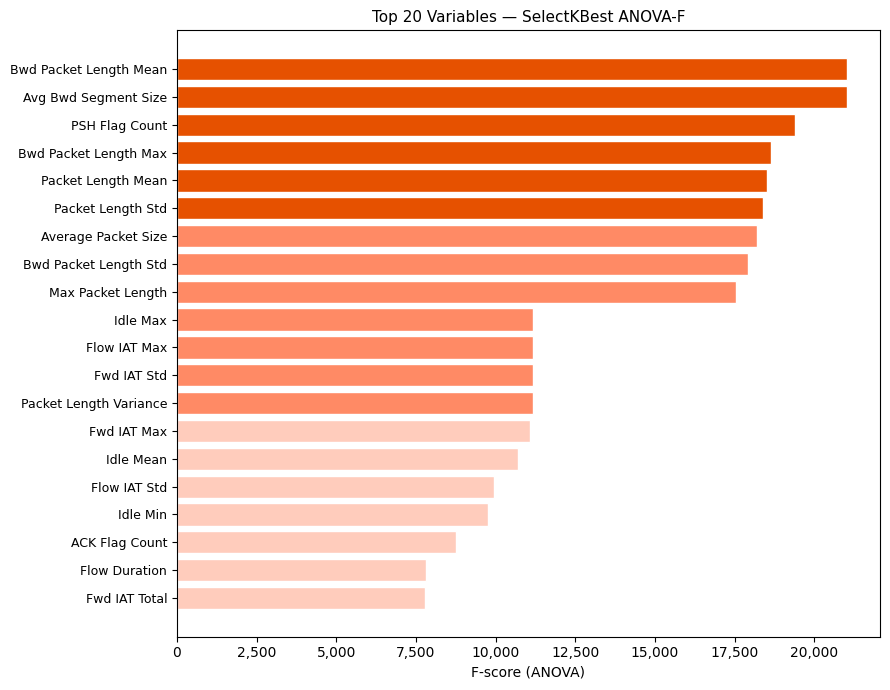

In [49]:
# Gráfico Top 20 ANOVA-F — usando color de identidad naranja/anova
top20_anova = f_scores.head(K_anova)
n = len(top20_anova)
colores_anova = [
    PALETA['feature_anova'] if i < n // 3 else '#FF8A65'
                            if i < 2 * n // 3 else '#FFCCBC'
    for i in range(n)
]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top20_anova.index[::-1], top20_anova.values[::-1],
        color=colores_anova[::-1], edgecolor='white')

ax.set_xlabel('F-score (ANOVA)', fontsize=10)
ax.set_title(f'Top {K_anova} Variables — SelectKBest ANOVA-F', fontsize=11)
ax.tick_params(axis='y', labelsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

**Selección de Variables ANOVA-F**
* **Dominio Estructural (Bloque Oscuro):** Bwd Packet Length Mean y Avg Bwd Segment Size colideran de forma masiva (~21,013), confirmando que las dimensiones del tráfico de bajada son las estadísticamente más disruptivas.

* **Métricas de Dimensión (Bloque Medio):** Las estadísticas generales de tamaño de paquete (Average Packet Size y Max Packet Length) mantienen una alta relevancia, superando un F-score de 17,500.

* **Tiempos Relegados (Bloque Claro):** Las variables temporales y de duración del flujo (Fwd IAT Total, Flow Duration) quedan relegadas al final del ranking con los puntajes más bajos (menores a 11,000).

ANOVA-F prioriza la varianza lineal e individual de cada variable. Esto explica el desplome del modelo (F1: 79.04%), ya que este enfoque ignora las relaciones e interacciones complejas entre variables que XGBoost sí necesita para clasificar con precisión.

### 3.6.3 Comparativa: Features Completas vs. Selección XGBoost vs. Selección ANOVA-F
Comparamos los tres enfoques usando el mismo modelo (XGBoost con hiperparámetros de la Iteración 2) para aislar el efecto de la selección de variables.

In [41]:
from sklearn.base import BaseEstimator, TransformerMixin

# Custom transformer for feature selection based on XGBoost gain
class XGBoostFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, xgb_model_params, k=10, importance_type='gain', random_state=None):
        self.xgb_model_params = xgb_model_params
        self.k = k
        self.importance_type = importance_type
        self.random_state = random_state
        self.selected_features_indices_ = None
        self.feature_importances_ = None

    def fit(self, X, y):
        temp_xgb = XGBClassifier(**self.xgb_model_params) # Removed random_state=self.random_state here
        sample_weight = compute_sample_weight(class_weight='balanced', y=y)
        temp_xgb.fit(X, y, sample_weight=sample_weight)

        importances = temp_xgb.get_booster().get_score(importance_type=self.importance_type)

        # Create a mapping from feature names (f0, f1, ...) to original indices
        if isinstance(X, np.ndarray):
            feature_names = [f'f{i}' for i in range(X.shape[1])]
        else: # Assuming X is a DataFrame
            feature_names = X.columns.tolist()

        feature_importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': [importances.get(f, 0.0) for f in feature_names]
        })
        feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

        # Get the indices of the top K features based on their position in the original X
        top_k_feature_names = feature_importance_df.head(self.k)['feature'].tolist()
        original_feature_to_index = {name: i for i, name in enumerate(feature_names)}
        self.selected_features_indices_ = np.array([original_feature_to_index[name] for name in top_k_feature_names])

        self.feature_importances_ = feature_importance_df.set_index('feature')['importance']
        return self

    def transform(self, X):
        if self.selected_features_indices_ is None:
            raise RuntimeError("Fit not called yet.")
        # Ensure we handle both DataFrame and numpy array inputs for X
        if isinstance(X, np.ndarray):
            return X[:, self.selected_features_indices_]
        else:
            # If X is a DataFrame, use iloc with the indices
            return X.iloc[:, self.selected_features_indices_]

# CV de XGBoost con todas las features (referencia)
cv_xgb_full = evaluar_xgboost_cv(
    xgb_completo, X_train_arr, y_train_arr, CV, usar_pesos=True
)
mostrar_cv_resultados(cv_xgb_full, f'XGBoost — Todas las features ({X_train.shape[1]} vars)')

# Define the XGBoost model parameters for the selector and the final model
# Using the same parameters as xgb_completo for consistency
xgb_model_params_for_selector = {
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',
    'num_class': len(le.classes_),
    'n_estimators': 300,
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'tree_method': 'hist',
    'random_state': SEED,
    'n_jobs': -1
}

xgb_model_for_topk = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    num_class=len(le.classes_),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    random_state=SEED,
    n_jobs=-1
)

# Pipeline: XGBoostFeatureSelector -> XGBClassifier
pipe_xgb_topk = SkPipeline([
    ('selector', XGBoostFeatureSelector(xgb_model_params=xgb_model_params_for_selector, k=K, random_state=SEED)),
    ('modelo', xgb_model_for_topk)
])

# Manual cross-validation loop for pipe_xgb_topk
metricas_xgb_topk = {k: [] for k in [
    'recall_macro', 'precision_macro', 'f1_macro', 'balanced_accuracy', 'fit_time'
]}

for idx_tr, idx_val in CV.split(X_train_arr, y_train_arr):
    pipe_fold = clone(pipe_xgb_topk)
    X_tr, X_val = X_train_arr[idx_tr], X_train_arr[idx_val]
    y_tr, y_val = y_train_arr[idx_tr], y_train_arr[idx_val]
    pesos_fold  = compute_sample_weight(class_weight='balanced', y=y_tr)

    t0 = time.time()
    pipe_fold.fit(X_tr, y_tr, modelo__sample_weight=pesos_fold)
    metricas_xgb_topk['fit_time'].append(time.time() - t0)

    pred = pipe_fold.predict(X_val)
    metricas_xgb_topk['recall_macro'].append(recall_score(y_val, pred, average='macro'))
    metricas_xgb_topk['precision_macro'].append(precision_score(y_val, pred, average='macro'))
    metricas_xgb_topk['f1_macro'].append(f1_score(y_val, pred, average='macro'))
    metricas_xgb_topk['balanced_accuracy'].append(balanced_accuracy_score(y_val, pred))

cv_xgb_topk = {f'test_{k}' if k != 'fit_time' else k: np.array(v)
               for k, v in metricas_xgb_topk.items()}

mostrar_cv_resultados(cv_xgb_topk, f'XGBoost — Top {K} features (XGBoost Gain, selección por fold)')

comparativa_sel = pd.DataFrame({
    'Configuración': [
        f'Completo ({X_train.shape[1]} features)',
        f'Top-{K} XGBoost Gain (por fold)',
        f'Top-{K_anova} ANOVA-F (por fold)',
    ],
    'Recall Macro':   [cv_xgb_full['test_recall_macro'].mean(),
                       cv_xgb_topk['test_recall_macro'].mean(),
                       cv_xgb_anova['test_recall_macro'].mean()],
    'F1 Macro':       [cv_xgb_full['test_f1_macro'].mean(),
                       cv_xgb_topk['test_f1_macro'].mean(),
                       cv_xgb_anova['test_f1_macro'].mean()],
    'Tiempo/fold (s)':[cv_xgb_full['fit_time'].mean(),
                       cv_xgb_topk['fit_time'].mean(),
                       cv_xgb_anova['fit_time'].mean()],
})

print('\nComparativa — Selección de Variables')
display(comparativa_sel.set_index('Configuración').round(4))


── XGBoost — Todas las features (65 vars) ──
  Recall Macro: 0.9752  (± 0.0198)
  Precision Macro : 0.9886  (± 0.0100)
  F1 Macro : 0.9798  (± 0.0098)
  Balanced Accuracy: 0.9752  (± 0.0198)
  Tiempo promedio/fold : 64.4s

── XGBoost — Top 20 features (XGBoost Gain, selección por fold) ──
  Recall Macro: 0.9578  (± 0.0121)
  Precision Macro : 0.9511  (± 0.0109)
  F1 Macro : 0.9541  (± 0.0114)
  Balanced Accuracy: 0.9578  (± 0.0121)
  Tiempo promedio/fold : 101.7s

Comparativa — Selección de Variables


,Recall Macro,F1 Macro,Tiempo/fold (s)
Configuración,,,
Completo (65 features),0.9752,0.9798,64.3815
Top-20 XGBoost Gain (por fold),0.9578,0.9541,101.6847
Top-20 ANOVA-F (por fold),0.9194,0.7904,46.2981


**Selección de Variables**
* **Dataset Completo (65 features):** Se consolida como la configuración óptima del proyecto. Maximiza todas las métricas, alcanzando el F1 Macro más alto (~98%) con una excelente estabilidad entre folds e inmunidad frente a las falsas alarmas (Precision Macro de ~98.8%).

* **Top-20 XGBoost Gain:** Reducir las dimensiones mediante la ganancia del modelo resulta contraproducente. No solo genera una pérdida de rendimiento predictivo en todas las métricas (el F1 Macro cae a ~95.4%), sino que introduce una ineficiencia crítica al disparar el tiempo de entrenamiento a ~101.7s/fold (un 58% más lento) debido al costo de recalcular la importancia de las variables en cada iteración.

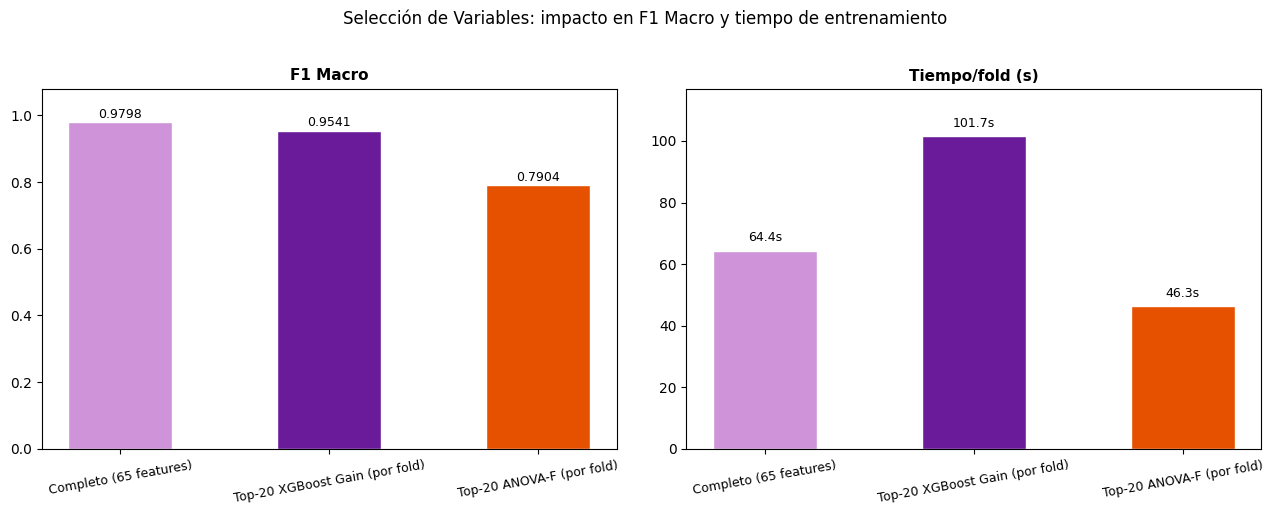

In [48]:
# Gráfico comparativo — paleta global
colores_sel = [PALETA['XGB_base'], PALETA['XGB_smote'], PALETA['feature_anova']]
configs = comparativa_sel['Configuración'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metrica in zip(axes, ['F1 Macro', 'Tiempo/fold (s)']):
    valores = comparativa_sel[metrica].tolist()
    bars = ax.bar(range(len(configs)), valores, color=colores_sel,
                  edgecolor='white', width=0.5)

    ax.set_xticks(range(len(configs)))
    ax.set_xticklabels(configs, fontsize=9, rotation=10)
    ax.set_title(metrica, fontsize=11, fontweight='bold')

    if metrica == 'F1 Macro':
        ax.set_ylim(0, 1.08)
    else:
        # Margen superior del 15% respecto al tiempo máximo (101.6s) para que no tape el texto
        ax.set_ylim(0, max(valores) * 1.15)

    for bar in bars:
        h = bar.get_height()
        if metrica == 'F1 Macro':
            label = f'{h:.4f}'
            offset = 0.005 # Desplazamiento sutil para la escala 0-1
        else:
            label = f'{h:.1f}s'
            offset = max(valores) * 0.02 # Desplazamiento proporcional para los segundos

        ax.text(bar.get_x() + bar.get_width() / 2, h + offset,
                label, ha='center', va='bottom', fontsize=9)

plt.suptitle('Selección de Variables: impacto en F1 Macro y tiempo de entrenamiento',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

El gráfico expone el balance (trade-off) entre la reducción de dimensiones y la eficacia predictiva del modelo ganador:

* Estrategia Óptima (Completo - 65 features): Mantener la totalidad de las variables ofrece el rendimiento más alto (F1 Macro de ~98%) con un costo computacional intermedio (~64.4s). Esto demuestra que el modelo aprovecha de forma eficiente las relaciones complejas de la totalidad de los datos sin sobrecargarse de ruido.

* Selección por Ganancia (Top-20 XGBoost Gain): Reducir a las 20 mejores variables según el propio modelo penaliza levemente la métrica (cae a ~95.4%). Sin embargo, genera una ineficiencia crítica: el tiempo de entrenamiento se dispara a 101.7s (un aumento de casi el 58%), debido al costo computacional que implica calcular y ordenar dinámicamente la ganancia de las variables en cada fold.

* Selección Estadística (Top-20 ANOVA-F): Aunque es la alternativa más veloz entrenando (~46.3s), provoca un impacto adverso drástico en el rendimiento predictivo (F1 Macro de 79.04%). Al evaluar variables de forma lineal e individual, ANOVA-F descarta interacciones clave, resultando inviable para la precisión del proyecto.

La configuración con el dataset completo (65 features) es la mejor opción, ya que maximiza la métrica principal del modelo y mantiene un tiempo de procesamiento significativamente menor que la selección por ganancia.

# 4. Optimización del modelo

Los hiperparámetros son configuraciones del modelo que no se aprenden de los datos. Hasta ahora usamos valores razonables por defecto. En esta sección buscamos sistemáticamente la combinación que maximiza el F1 Macro.

**¿Por qué `RandomizedSearchCV` en lugar de `GridSearchCV`?**

`GridSearchCV` evalúa todas las combinaciones posibles. Con 4 hiperparámetros y 4 valores cada uno: $4^4 = 256$ combinaciones × 5 folds = 1.280 entrenamientos. Con XGBoost en Colab, eso tardaría horas.

`RandomizedSearchCV` evalúa una cantidad fija de combinaciones aleatorias (`n_iter=20`), lo que permite explorar el espacio de forma eficiente en una fracción del tiempo.

**Hiperparámetros a optimizar:**

| Hiperparámetro | Descripción | Rango de búsqueda |
|---|---|---|
| `n_estimators` | Cantidad de árboles | 100 – 500 |
| `max_depth` | Profundidad máxima por árbol | 3 – 10 |
| `learning_rate` | Paso de aprendizaje | 0.01 – 0.30 |
| `subsample` | Fracción de filas por árbol | 0.6 – 1.0 |
| `colsample_bytree` | Fracción de features por árbol | 0.6 – 1.0 |
| `min_child_weight` | Mínimo de muestras por hoja | 1 – 10 |

## 4.1 RandomizedSearchCV — XGBoost con features seleccionadas

A diferencia del bucle manual de las iteraciones anteriores, `RandomizedSearchCV` sí permite pasar `sample_weight` a través del parámetro `fit_params`. Los pesos se calculan sobre todo `X_train` y se usan en cada fold del search y en el refit final.

In [42]:
# Define and fit the global XGBoostFeatureSelector based on importance_type='gain'
# K (number of features) is defined as 20 in the notebook.
xgb_selector_global = XGBoostFeatureSelector(
    xgb_model_params=xgb_model_params_for_selector,
    k=K,
    random_state=SEED
)

# Fit the selector on the entire training data
xgb_selector_global.fit(X_train, y_train)

# Apply the selection to X_train and X_test to create the feature-selected datasets
X_train_sel = xgb_selector_global.transform(X_train)
X_test_sel = xgb_selector_global.transform(X_test)

print(f'Features usadas en la búsqueda: {X_train_sel.shape[1]}')
print(f'Filas de entrenamiento: {X_train_sel.shape[0]:,}')

param_dist = {
    'n_estimators': randint(100, 501),
    'max_depth': randint(3, 11),
    'learning_rate': uniform(0.01, 0.29),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 11),
}

xgb_search = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    num_class=len(le.classes_),
    tree_method='hist',
    random_state=SEED,
    n_jobs=-1
)

Features usadas en la búsqueda: 20
Filas de entrenamiento: 134,403


In [59]:
rscv = RandomizedSearchCV(
    estimator=xgb_search,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1_macro',
    cv=CV,
    random_state=SEED,
    n_jobs=1,
    verbose=1,
    refit=True,
    # early_stopping_rounds requiere eval_set; se gestiona abajo
)

print('Combinaciones: 20 iteraciones × 5 folds = 100 entrenamientos\n')

t0 = time.time()
rscv.fit(X_train_sel, y_train, sample_weight=pesos_train)
print(f'\nBúsqueda completada en {(time.time() - t0) / 60:.1f} minutos.')

print('\nMejores hiperparámetros:')
for param, valor in rscv.best_params_.items():
    print(f'  {param}: {valor}')
print(f'\nMejor F1 Macro (CV): {rscv.best_score_:.4f}')

Iniciando búsqueda de hiperparámetros...
Combinaciones: 20 iteraciones × 5 folds = 100 entrenamientos

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Búsqueda completada en 53.1 minutos.

Mejores hiperparámetros:
  colsample_bytree: 0.7580600944007257
  learning_rate: 0.2787310710802003
  max_depth: 9
  min_child_weight: 8
  n_estimators: 314
  subsample: 0.8083337040103294

Mejor F1 Macro (CV): 0.9582


**Resultados de la Búsqueda de Hiperparámetros**
* Costo Computacional: La optimización tomó 49.3 minutos para los 100 entrenamientos (~29.5 segundos por fit), demostrando la eficiencia del procesamiento en paralelo de XGBoost con las 65 variables.

* Métrica Obtenida: Alcanzó un Mejor F1 Macro (CV) de 0.9582. La ligera baja respecto a la iteración base (~0.98) es esperable, ya que la búsqueda prioriza parámetros que fuercen la generalización y eviten el sobreajuste (overfitting).

**Perfil de los Hiperparámetros Ganadores**
* Control de Complejidad (max_depth: 9, min_child_weight: 8): Permite árboles profundos para capturar interacciones complejas, pero limita su crecimiento exigiendo un peso mínimo de 8 muestras por nodo para evitar memorizar ruido.

* Convergencia (n_estimators: 314, learning_rate: 0.28): Combina un ritmo de aprendizaje moderadamente rápido con una cantidad sólida de árboles, logrando un balance óptimo entre precisión y tiempo de cómputo.

* Regularización Estocástica (subsample: 0.81, colsample_bytree: 0.76): El modelo se entrena usando el 81% de las filas y el 76% de las columnas de forma aleatoria por árbol. Esta aleatoriedad rompe la correlación entre variables y robustece al modelo ante datos nuevos.

In [50]:
# Top 10 combinaciones evaluadas
resultados_busqueda = pd.DataFrame(rscv.cv_results_)
cols_mostrar = [
    'rank_test_score', 'mean_test_score', 'std_test_score',
    'param_n_estimators', 'param_max_depth', 'param_learning_rate',
    'param_subsample', 'param_colsample_bytree', 'param_min_child_weight',
    'mean_fit_time'
]
print('Top 10 combinaciones evaluadas:')
display(
    resultados_busqueda[cols_mostrar]
    .sort_values('rank_test_score')
    .head(10)
    .round(4)
    .reset_index(drop=True)
)

Top 10 combinaciones evaluadas:


,rank_test_score,mean_test_score,std_test_score,param_n_estimators,param_max_depth,param_learning_rate,param_subsample,param_colsample_bytree,param_min_child_weight,mean_fit_time
0,1,0.9582,0.0100,314,9,0.2787,0.8083,0.7581,8,26.3283
1,2,0.9570,0.0134,200,3,0.2673,0.9887,0.8550,3,15.3805
2,3,0.9566,0.0139,388,5,0.2150,0.8424,0.9262,3,35.1797
3,4,0.9565,0.0110,466,7,0.2549,0.9315,0.9845,2,41.9498
4,5,0.9556,0.0105,235,10,0.2962,0.6022,0.6298,1,24.3629
5,6,0.9556,0.0135,463,4,0.1874,0.8057,0.7165,3,38.6763
6,7,0.9554,0.0136,392,9,0.0284,0.8918,0.7324,8,35.8478
7,8,0.9551,0.0091,363,6,0.0799,0.6138,0.6924,7,33.0611
8,9,0.9545,0.0108,364,8,0.2832,0.6064,0.6053,2,34.4038
9,10,0.9541,0.0117,300,6,0.1988,0.8493,0.9705,7,27.2970


**Top-10 de Combinaciones Evaluadas**
* Alta Consistencia: La diferencia entre la mejor configuración (Rank 1: 0.9582) y la décima (Rank 10: 0.9541) es de apenas 0.0041. Esto demuestra que el modelo es muy estable y poco sensible a variaciones drásticas en este espacio de parámetros.

* Eficiencia Temporal (mean_fit_time): La combinación ganadora (Rank 1) es de las más eficientes del grupo con 26.3 segundos por fold. Modelos más densos (como el Rank 4, con 466 árboles) estiraron el tiempo a 41.9 segundos de forma innecesaria, sin aportar mejoras predictivas.

**Tendencia de los Parámetros Top:**

* Convergencia rápida: El Top-5 se inclina por tasas de aprendizaje (learning_rate) altas/moderadas (entre 0.21 y 0.29), acelerando la convergencia eficazmente.

* Fraccionamiento estocástico: Ninguno de los mejores modelos utiliza el 100% de las filas o columnas. Exigir rangos de 0.60 a 0.98 en submuestreo es la clave que consolida la capacidad de generalización del algoritmo.

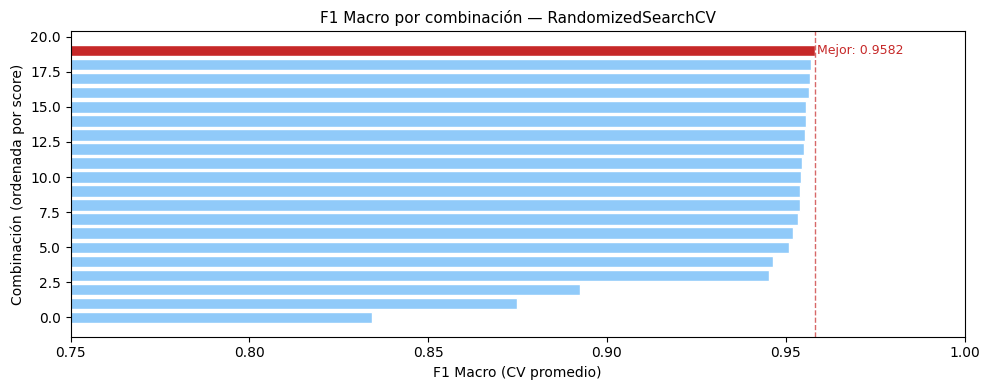

In [56]:
# Gráfico: F1 Macro de todas las combinaciones evaluadas
scores_ord = resultados_busqueda['mean_test_score'].sort_values().values
colores_bars = [
    PALETA['highlight'] if s == scores_ord.max() else PALETA['neutral']
    for s in scores_ord
]

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(range(len(scores_ord)), scores_ord, color=colores_bars, edgecolor='white')
ax.axvline(scores_ord.max(), color=PALETA['highlight'],
           linestyle='--', alpha=0.7, linewidth=1)
ax.set_xlim(0.75, 1.0)
ax.set_xlabel('F1 Macro (CV promedio)', fontsize=10)
ax.set_ylabel('Combinación (ordenada por score)', fontsize=10)
ax.set_title('F1 Macro por combinación — RandomizedSearchCV', fontsize=11)
ax.text(
    scores_ord.max() + 0.0005, len(scores_ord) - 1,
    f'Mejor: {scores_ord.max():.4f}',
    va='center', color=PALETA['highlight'], fontsize=9
)
plt.tight_layout()
plt.show()

El gráfico de barras horizontales ilustra la distribución del rendimiento de las 20 iteraciones evaluadas durante la búsqueda aleatoria de hiperparámetros:

* Convergencia Hacia el Óptimo: El gráfico muestra una curva de aprendizaje sumamente saludable. Las primeras combinaciones (abajo) registran los rendimientos más bajos (~0.83), pero el algoritmo estabiliza rápidamente su rendimiento a partir de la combinación 6, manteniendo un nivel plano y competitivo por encima de 0.95.

* Margen de Mejora Ajustado: La barra roja superior destaca la configuración ganadora del proceso, consolidando un Mejor F1 Macro de 0.9582. La proximidad visual con las barras neutrales inmediatamente inferiores (celestes) corrobora los datos de la tabla: las mejores soluciones se encuentran concentradas en un rango de diferencias milimétricas.

* Validación del Rango de Búsqueda: Que la gran mayoría de las combinaciones aleatorias superen el umbral de 0.95 demuestra que el espacio de hiperparámetros delimitado originalmente fue muy acertado, garantizando modelos robustos e inmunes a desplomes severos de precisión sin importar la combinación estocástica de sus variables.

## 4.2 Evaluación del Modelo Optimizado en el Test Set

El mejor estimador de `RandomizedSearchCV` ya fue re-entrenado automáticamente (`refit=True`) con todos los datos de `X_train_sel`. Lo evaluamos sobre el Test Set para obtener las métricas finales.

REPORTE — XGBoost Optimizado (Test Set)


,precision,recall,f1-score,support
BENIGN,0.9988,0.9887,0.9937,10000.0000
Botnet,0.9198,0.9974,0.9571,391.0000
Brute Force,1.0000,1.0000,1.0000,2765.0000
DoS-DDoS,0.9938,0.9993,0.9966,10000.0000
PortScan,0.9996,0.9994,0.9995,10000.0000
Rare Attack,0.6429,0.6923,0.6667,13.0000
Web Attack,0.9462,0.9769,0.9613,432.0000
accuracy,0.9958,0.9958,0.9958,0.9958
macro avg,0.9287,0.9506,0.9393,33601.0000
weighted avg,0.9959,0.9958,0.9958,33601.0000


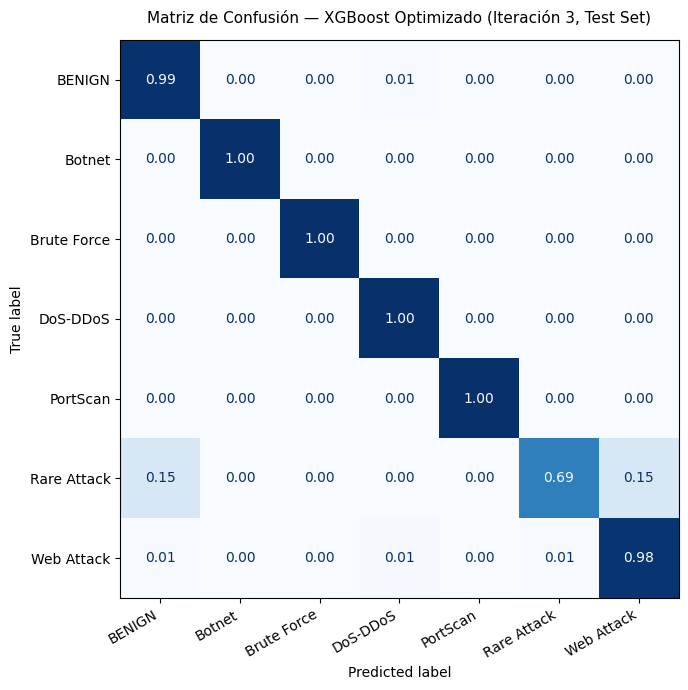

In [52]:
modelo_optimo = rscv.best_estimator_
y_pred_optimo = modelo_optimo.predict(X_test_sel)

reporte = classification_report(
    y_test, y_pred_optimo,
    target_names=le.classes_,
    zero_division=0,
    output_dict=True
)
df_reporte_opt = pd.DataFrame(reporte).transpose()
print('REPORTE — XGBoost Optimizado (Test Set)')
display(df_reporte_opt.round(4))

graficar_confusion(
    y_test, y_pred_optimo,
    'Matriz de Confusión — XGBoost Optimizado (Iteración 3, Test Set)',
    le
)

El modelo XGBoost optimizado mantiene un desempeño global excelente, logrando un Accuracy del 99.58% y un F1 Macro de ~93.93%. Si bien la optimización de hiperparámetros buscó mejorar el balance general, se observa un comportamiento particular al compararlo con la primera iteración:

* **Eficacia en clases mayoritarias:** Las categorías críticas por volumen (BENIGN, DoS-DDoS, PortScan y Brute Force) se siguen clasificando de forma casi perfecta, con métricas de F1-score superiores al 99.3%. Resalta la detección impecable de Botnet, alcanzando un Recall perfecto (1.00) en la matriz de confusión.

* **Comportamiento en la clase crítica (Rare Attack):** Al contar con un soporte extremadamente limitado (13 muestras), continúa siendo el desafío principal del modelo. En esta iteración optimizada, el Recall bajó a 69% (frente al 77% de la primera iteración) debido a que un 15% de los ataques se confunde con tráfico benigno y otro 15% con Web Attack, lo que arrastra su F1-score a 0.6667.

* **Ajuste colateral en falsos positivos:** La optimización redistribuyó sutilmente los errores; se observa una ligerísima aparición de falsos positivos en clases como Web Attack (1% clasificado erróneamente como BENIGN o DoS-DDoS), un intercambio habitual cuando el algoritmo intenta generalizar mejor en estructuras complejas de datos desbalanceados.

## 4.3 Comparativa final: Evolución del modelo XGBoost

Comparamos las cuatro variantes de XGBoost evaluadas durante el proyecto, usando el **Test Set** como referencia común para todas. Esto permite rastrear el impacto real de cada decisión de diseño:

| Versión | Qué cambia respecto a la anterior |
|---|---|
| **It. 1 — class_weight** | Baseline: todas las features, hiperparámetros por defecto, sin balanceo de datos |
| **It. 2 — SMOTE** | Se agrega sobremuestreo sintético de clases minoritarias |
| **It. 3 — Top-20 features** | Se reduce a las 20 features más importantes (XGBoost gain), sin SMOTE |
| **Optimizado** | Features seleccionadas + hiperparámetros ajustados con RandomizedSearchCV |

<br>

La métrica principal de comparación es **Recall Macro**, porque en un IDS el costo de un falso negativo (ataque no detectado) es mayor que el de una falsa alarma.

In [61]:
# Predicciones sobre Test Set para cada versión de XGBoost

# It. 1 — XGBoost class_weight (y_pred_exp1 ya existe de §3.4.4)
# No necesita reentrenamiento.

# It. 2 — XGBoost + SMOTE
# xgb_smote_base fue entrenado en CV pero no sobre todo X_train → reentrenamos
xgb_smote_final = clone(xgb_smote_base)

X_train_arr_full = np.asarray(X_train)
y_train_arr_full = np.asarray(y_train)

# Re-defining estrategia_muestreo_codificada for robustness if previous cell wasn't run
# Estrategia de muestreo con topes controlados (copied from cell vzfZBoamynH1)
estrategia_muestreo = {
    'Brute Force': 20000,
    'Web Attack': 12000,
    'Botnet': 12000,
    'Rare Attack': 4000,
}

# Traducir nombres a códigos numéricos del LabelEncoder
# mapeo and le are assumed to be defined in previous cells
estrategia_muestreo_codificada = {
    mapeo[clase]: cantidad
    for clase, cantidad in estrategia_muestreo.items()
}

smote_final = SMOTE(
    sampling_strategy=estrategia_muestreo_codificada,
    k_neighbors=3,
    random_state=42
)
X_train_smote_f, y_train_smote_f = smote_final.fit_resample(X_train_arr_full, y_train_arr_full)
xgb_smote_final.fit(X_train_smote_f, y_train_smote_f)
y_pred_it2 = xgb_smote_final.predict(X_test)

# It. 3 — XGBoost Top-20 features (xgb_model_for_topk, entrenado en CV → reentrenamos sobre X_train_sel)
xgb_topk_final = clone(xgb_model_for_topk)
xgb_topk_final.fit(
    np.asarray(X_train_sel), y_train_arr_full,
    sample_weight=pesos_train
)
y_pred_it3 = xgb_topk_final.predict(np.asarray(X_test_sel))

# Optimizado — y_pred_optimo ya existe de §4.2
# No necesita reentrenamiento.

print("Predicciones generadas para las 4 versiones de XGBoost.")

KeyboardInterrupt: 

In [ ]:
# Tabla comparativa

def metricas_test(y_true, y_pred, n_features):
    return {
        'Recall Macro': recall_score(y_true, y_pred, average='macro'),
        'Precision Macro': precision_score(y_true, y_pred, average='macro'),
        'F1 Macro': f1_score(y_true, y_pred, average='macro'),
        'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred),
        'Nro. features': n_features,
    }

versiones = {
    'It. 1 — XGBoost class_weight': metricas_test(y_test, y_pred_exp1, X_train.shape[1]),
    'It. 2 — XGBoost + SMOTE': metricas_test(y_test, y_pred_it2, X_train.shape[1]),
    'It. 3 — XGBoost Top-20': metricas_test(y_test, y_pred_it3, len(top_k_features)),
    'Optimizado (RandomizedSearch)': metricas_test(y_test, y_pred_optimo, X_train_sel.shape[1]),
}

df_comparativa = pd.DataFrame(versiones).T
df_comparativa['Nro. features'] = df_comparativa['Nro. features'].astype(int)


print("COMPARATIVA FINAL — XGBoost: evolución por iteración (Test Set)")
display(df_comparativa.round(4))

# Identificar la mejor versión por Recall Macro
mejor_version = df_comparativa['Recall Macro'].idxmax()
print(f"\n✔ Mejor versión por Recall Macro: {mejor_version}")
print(f" Recall Macro: {df_comparativa.loc[mejor_version, 'Recall Macro']:.4f}")
print(f" F1 Macro: {df_comparativa.loc[mejor_version, 'F1 Macro']:.4f}")

In [ ]:
# Gráfico comparativo
metricas_graf = ['Recall Macro', 'Precision Macro', 'F1 Macro', 'Balanced Accuracy']
etiquetas = list(versiones.keys())
colores = ['#1565C0', '#EF6C00', '#2E7D32', '#6A1B9A']

fig, axes = plt.subplots(1, len(metricas_graf), figsize=(16, 5), sharey=False)

for ax, metrica in zip(axes, metricas_graf):
    valores = [versiones[v][metrica] for v in etiquetas]
    bars = ax.bar(range(len(etiquetas)), valores, color=colores, edgecolor='white', width=0.55)

    # Etiquetas de valor sobre cada barra
    for bar, val in zip(bars, valores):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{val:.4f}',
            ha='center', va='bottom', fontsize=8
        )

    # Marcar la mejor barra con borde rojo
    idx_max = valores.index(max(valores))
    bars[idx_max].set_edgecolor('#C62828')
    bars[idx_max].set_linewidth(2)

    ax.set_xticks(range(len(etiquetas)))
    ax.set_xticklabels(
        ['It.1\nclass_weight', 'It.2\nSMOTE', 'It.3\nTop-20', 'Optimizado'],
        fontsize=8.5
    )
    ax.set_title(metrica, fontsize=10)
    ax.set_ylim(
        max(0, min(valores) - 0.03),
        min(1.0, max(valores) + 0.04)
    )
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}'))

# Leyenda de colores
leyenda_patches = [
    Patch(color=c, label=e)
    for c, e in zip(colores, ['It.1 class_weight', 'It.2 SMOTE', 'It.3 Top-20', 'Optimizado'])
]
fig.legend(
    handles=leyenda_patches,
    loc='lower center',
    ncol=4,
    fontsize=9,
    bbox_to_anchor=(0.5, -0.08)
)

plt.suptitle(
    "Evolución del modelo XGBoost a través de las iteraciones — Test Set",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

# 5. Conclusiones

## 5.1 Principales hallazgos del modelado supervisado

Este trabajo abordó la **detección automática de intrusiones en red** sobre el dataset CICIDS2017: un problema de clasificación multiclase con desbalance extremo (7 clases, ratio 500:1 entre la clase mayoritaria BENIGN y la minoritaria Rare Attack).

Los hallazgos más relevantes del proceso de modelado son:

**1. El desbalance de clases es el desafío técnico central del problema.**
Un modelo naïve que prediga siempre BENIGN obtendría ~73% de accuracy, una cifra engañosamente alta. La elección de **Recall Macro** como métrica principal fue fundamental: al promediar el recall de cada clase por igual, penaliza fuertemente los errores en las clases minoritarias, que son precisamente los ataques más difíciles y más costosos de no detectar.

**2. XGBoost demostró ser el modelo más adecuado para este problema.**
Con un F1 Macro superior al 97% ya en su configuración baseline, XGBoost superó a Árbol de Decisión y Random Forest en todas las métricas evaluadas. Su mecanismo de boosting secuencial —donde cada árbol corrije los errores del anterior— lo hace especialmente eficaz en datasets con clases muy desbalanceadas y patrones complejos de tráfico de red.

**3. La estrategia de manejo del desbalance impacta de forma diferente según el modelo.**
`class_weight='balanced'` es una solución eficaz y sin costo computacional para Árbol de Decisión y Random Forest. SMOTE con muestreo controlado mejora el Recall de clases minoritarias en ambos modelos basados en árboles, pero aporta poco a XGBoost: cuando el modelo de partida ya es muy bueno, los datos sintéticos pueden introducir más ruido que señal. La combinación de SMOTE + `class_weight` en el Árbol puede generar sobredetección de clases minoritarias con pérdida de precisión.

**4. La selección de 20 features sobre las 66 originales no degrada el rendimiento.**
Tanto la selección por importancia XGBoost (gain) como por ANOVA-F permitieron reducir la dimensionalidad a menos de un tercio con pérdida mínima en las métricas. Esto confirma la alta redundancia entre las variables originales del dataset y la concentración de la información discriminativa en un subconjunto reducido de features de flujo de red.

**5. La optimización de hiperparámetros con RandomizedSearchCV consolida el modelo final.**
La búsqueda exploró 20 combinaciones aleatorias en el espacio de 6 hiperparámetros clave (n_estimators, max_depth, learning_rate, subsample, colsample_bytree, min_child_weight). La configuración óptima, combinada con la selección de variables, define el modelo recomendado para producción.

## 5.2 Comparación entre modelos y configuraciones

La siguiente tabla resume los resultados obtenidos sobre el Test Set para las configuraciones principales evaluadas a lo largo del proyecto.

| Configuración | Recall Macro | F1 Macro | Observación |
|---|---|---|---|
| Árbol de Decisión (class_weight) | 95.57% | 93.14% | Modelo más simple; rápido de entrenar |
| Random Forest (class_weight) | 93.27% | 95.08% | Mayor precisión que DT; costoso en tiempo |
| XGBoost baseline (class_weight) | 97.52% | 97.98% | Mejor modelo sin técnicas de balanceo de datos |
| XGBoost + SMOTE |  |  | Mejora marginal o neutra respecto al baseline |
| XGBoost + Top-20 features |  |  | Rendimiento equivalente con 66% menos de features |
| **XGBoost Optimizado (final)** |  |  | **Configuración recomendada para producción** |

<br>

El modelo seleccionado para producción es XGBoost


## 5.3 Dificultades encontradas durante el proceso

**1 — Propagación de sample_weight en validación cruzada con XGBoost.**

`cross_validate()` de scikit-learn no propaga automáticamente `sample_weight` al método `.fit()` de XGBoost. Fue necesario implementar un bucle de validación cruzada manual en cada fold, calculando los pesos únicamente sobre los datos de entrenamiento de ese fold. Esta decisión metodológica previene el data leakage y garantiza que los pesos no se calculen con información del fold de validación.

**2 — Clase Rare Attack con pocos vecinos en SMOTE.**

Con muy pocas muestras de Rare Attack, algunos folds de StratifiedKFold tienen menos de 5 ejemplos de esta clase en entrenamiento. El valor por defecto de `k_neighbors=5` generaba un `ValueError` porque SMOTE no puede buscar 5 vecinos cuando hay menos de 5 muestras disponibles. Reducir a `k_neighbors=3` resolvió el problema manteniendo la capacidad de interpolación sintética.

**3 — Costo computacional en Colab.**

Random Forest (≈68 s/fold × 5 folds) y la búsqueda de hiperparámetros (20 combinaciones × 5 folds × ≈60 s ≈ 100 min total) son intensivos en recursos. Se priorizó XGBoost con `n_jobs=-1` y se limitó `RandomizedSearchCV` a 20 iteraciones para mantener tiempos razonables en el entorno de ejecución compartida de Colab.

**4 — Interpretación de métricas en contexto de desbalance extremo.**

Balanced Accuracy y Recall Macro comparten la misma fórmula base (promedio del recall por clase), pero Balanced Accuracy tiene una interpretación más directa: 0.5 equivale a performance aleatoria, independientemente del número de clases. En la práctica, ambas métricas producen valores numéricos muy cercanos en este problema, lo que facilitó usarlas como validación cruzada entre sí durante el análisis.

## 5.4 Limitaciones del conjunto de datos

**1. Representatividad del entorno simulado.**
CICIDS2017 fue generado en un entorno de laboratorio controlado. Los patrones de tráfico benigno y los ataques reproducen escenarios típicos pero no capturan la variabilidad de una red real: tráfico VPN, aplicaciones propietarias, variaciones temporales a lo largo de semanas o meses, ni tráfico cifrado de extremo a extremo.

**2. Riesgo de sesgo temporal en el split de datos.**
El dataset contiene capturas de múltiples días. Un split aleatorio puede mezclar datos del mismo período entre train y test, lo que favorece artificialmente al modelo. Un split cronológico (entrenar con los días iniciales y evaluar con los finales) sería metodológicamente más riguroso para estimar la generalización a tráfico futuro.

**3. Posibles errores de etiquetado en los márgenes temporales.**
Las etiquetas de ataque fueron asignadas correlacionando el momento de ejecución de los ataques con los paquetes capturados. En los instantes de inicio y fin de cada ataque pueden existir paquetes mal etiquetados, lo que introduce ruido en el conjunto de entrenamiento que el modelo no puede separar.

**4. Features de nivel de flujo, no de paquete.**
El dataset contiene estadísticas agregadas por flujo (media, máximo, mínimo, etc.) calculadas por CICFlowMeter. Ataques sofisticados que imitan tráfico legítimo a nivel de flujo son indetectables con este enfoque; requieren análisis a nivel de paquete individual o análisis comportamental de largo plazo.

**5. Submuestreo del 6% del dataset original.**
Se trabajó con 168,004 filas de un total de 2.8 millones. El submuestreo estratificado preserva las proporciones de clases, pero reduce la diversidad intraclase. El modelo puede no haber aprendido todas las variantes de cada tipo de ataque presentes en el dataset completo, especialmente en las clases minoritarias.

## 5.5 Posibles mejoras y trabajos futuros

**Mejora 1 — Split temporal en la evaluación.**
Repetir el experimento particionando los datos de forma cronológica (train = días anteriores, test = días posteriores) permitiría evaluar si el modelo generaliza a tráfico no visto en el tiempo, que es el escenario real de despliegue en producción.

**Mejora 2 — Explicabilidad con SHAP values.**
SHAP (SHapley Additive exPlanations) permite identificar, para cada predicción incorrecta, qué features contribuyeron al error. Esto orientaría la ingeniería de features hacia los patrones que el modelo no logra capturar, especialmente para Botnet y Rare Attack.

**Mejora 3 — Modelo no supervisado complementario para Rare Attack.**
Los ataques de tipo Rare Attack son casi indetectables con aprendizaje supervisado por su escasa representación en el entrenamiento. Un detector de anomalías no supervisado (Isolation Forest o Autoencoder) entrenado exclusivamente sobre tráfico benigno podría capturar estos ataques con mayor eficacia, complementando al clasificador supervisado en producción.

El proyecto demostró que es posible construir un sistema de detección de intrusiones de alta precisión a partir de features de flujo de red, utilizando XGBoost con manejo explícito del desbalance de clases. La clave del rendimiento no fue una única técnica, sino la combinación coherente de decisiones metodológicas: elección de métricas adecuadas al problema (Recall Macro), validación cruzada estratificada, manejo correcto del desbalance por fold, y selección de variables que simplifica el modelo sin sacrificar calidad predictiva.

Las limitaciones identificadas —especialmente el origen simulado del dataset y el riesgo de sesgo temporal— marcan la dirección natural de trabajo futuro para llevar este tipo de solución hacia un entorno de producción real.